# 🔬 AI Project Cycle: Klasifikasi Penyakit Asam Lambung
## Naive Bayes — Multi-Class Classification — **VERSI FINAL (2 Revisi Client)**
---
**4 Kelas Diagnosis:** GERD, Tukak Lambung, Dispepsia, Gastritis
**Model:** BernoulliNB (baseline) + GaussianNB + ComplementNB Ensemble
**Fitur:** 24 fitur (20 gejala + 4 fitur engineering)
**Dataset:** Kaggle — Disease Prediction Using ML (**difokuskan ke penyakit lambung**)
**Validasi:** Stratified K-Fold CV + Evaluasi pada Data Asli (tanpa augmentasi)

### ✅ Perbaikan dari Versi Sebelumnya (dipertahankan):
1. **Split data DULU** sebelum augmentasi — mencegah data leakage
2. **BernoulliNB ditambahkan** sebagai baseline (lebih tepat untuk data biner 0/1)
3. **Chi-Square + Mutual Information** untuk validasi statistik seleksi fitur
4. **Dispepsia_Indicator dihapus** — nonzero hanya 0.38% data (noise tanpa sinyal)
5. **Confidence threshold** pada fungsi diagnosa (tolak jika < 60%)
6. **Noise augmentation** hanya pada training set — test set tetap distribusi asli

---

## 🆕 Dua Revisi Client yang Diterapkan di Notebook Ini

### Revisi 1 — Perbandingan Rasio Split 80:20 vs 70:30
Ditambahkan pada **Tahap 8B**. Kedua rasio dibandingkan memakai pipeline yang sama,
diulang 10 seed, lalu diuji signifikansinya dengan Wilcoxon.
**Hasil: kedua rasio setara secara statistik** (p > 0,05), sehingga 80:20 dipertahankan.

### Revisi 2 — Dataset difokuskan ke penyakit lambung saja
Diterapkan pada **Tahap 3**. Bucket `Normal` yang berisi 31 penyakit non-lambung
(penyakit kulit, alergi, malaria, dll) **tidak lagi diikutkan** ke pengolahan data.
Kelas berkurang dari 5 menjadi 4.

### ⚡ Optimasi Menyertai
Target augmentasi diturunkan dari **2.500 → 250 per kelas**. Setelah bucket `Normal`
dibuang, data menjadi jauh lebih seimbang sehingga augmentasi besar tidak lagi
diperlukan. Terbukti **menaikkan** F1-macro sekaligus memangkas porsi data sintetis
dari 90,3% menjadi 17,8% (dibuktikan pada **Tahap 8C**).

| Kondisi | Kelas | F1-Macro (rata-rata 10 seed) |
|---|---|---|
| Sebelum revisi | 5 (termasuk `Normal`) | 0,9639 ± 0,0249 |
| **Setelah 2 revisi + optimasi** | **4 (lambung saja)** | **0,9958 ± 0,0038** |

Selain naik, hasilnya juga menjadi **jauh lebih stabil** — simpangan bakunya turun dari
0,0249 menjadi 0,0038 (sekitar 6x lebih konsisten antar percobaan).

> ⚠️ **Notebook ini tidak menimpa model produksi.** Sel ekspor dikunci
> (`EXPORT_MODEL = False`) agar `model_web/` yang melayani website tetap aman.

In [ ]:
# === CELL 1: INSTALL & IMPORT ===
!pip install -q scikit-learn imbalanced-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, ComplementNB, BernoulliNB
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.metrics import (classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay)
from collections import Counter
from scipy.stats import wilcoxon
import pickle, json as js, os, sys, subprocess
print("Setup selesai!")

## Tahap 1: Data Acquisition
Dataset: **Kaggle Disease Prediction Using Machine Learning**
Sumber: https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning

**Profil Dataset:**
- Total sampel: 4.962 baris (Training + Testing digabung)
- Jumlah fitur: 132 gejala (biner: 0/1)
- Jumlah kelas asli: 41 penyakit
- Target revisi: petakan ke 5 kelas gangguan GI

In [ ]:
# === CELL 2: MUAT DATASET (Colab: clone otomatis / Lokal: baca langsung) ===
# Menggantikan unduhan Kaggle agar notebook bisa Run-all tanpa API key.
REPO_URL = "https://github.com/apaajadigital/Stomcare.git"
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    CLONE_DIR = '/content/Stomcare'
    if not os.path.isdir(CLONE_DIR):
        print("Terdeteksi Google Colab - meng-clone repository ...")
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, CLONE_DIR], check=True)
    else:
        print("Repository sudah tersedia, clone dilewati.")
    BASE = CLONE_DIR
else:
    BASE = os.getcwd()

data_dir = os.path.join(BASE, 'disease-prediction-using-machine-learning')
assert os.path.isdir(data_dir), f"Folder dataset tidak ditemukan: {data_dir}"

df_train = pd.read_csv(os.path.join(data_dir, 'Training.csv'))
df_test  = pd.read_csv(os.path.join(data_dir, 'Testing.csv'))
df_train.drop(columns=['Unnamed: 133'], errors='ignore', inplace=True)
df_test.drop(columns=['Unnamed: 133'],  errors='ignore', inplace=True)
df_all = pd.concat([df_train, df_test], ignore_index=True)

print(f"Lingkungan   : {'Google Colab' if IN_COLAB else 'Lokal'}")
print(f"Total sampel : {len(df_all)}, Fitur asli: {len(df_all.columns)-1}")
print(f"Penyakit unik: {df_all['prognosis'].nunique()}")

## Tahap 2: Feature Selection — 20 Gejala + 4 Feature Engineering = 24 Fitur

**Catatan Revisi:** Fitur dipilih berdasarkan relevansi klinis domain GI,
kemudian **divalidasi statistik menggunakan Chi-Square & Mutual Information**
pada Tahap 3.6 (setelah split, hanya dari training set).

**Fitur Engineering yang Dipertahankan (4, bukan 5):**
- `GERD_Indicator` = stomach\_pain × acidity
- `Infection_Indicator` = high\_fever × chills
- `Digestive_Distress` = abdominal\_pain × passage\_of\_gases
- `Gastritis_Indicator` = diarrhoea × belly\_pain

**Dihapus:** `Dispepsia_Indicator` (indigestion × itching) — nonzero hanya **48/12500 (0.38%)**

In [3]:
# === CELL 3: DEFINISI FITUR + KAMUS TERJEMAHAN INDONESIA ===
# 20 gejala terpilih berdasarkan relevansi klinis GI
# Validasi statistik dilakukan pada Cell 3B (Chi-Square semua 132 fitur)
# CATATAN: Setelah menjalankan Cell 3B di Colab, update dengan RECOMMENDED_FEATURES

SELECTED_FEATURES = [
    # GI Core: sangat spesifik untuk kondisi asam lambung
    'stomach_pain',               # GERD, Tukak
    'acidity',                    # GERD khas
    'indigestion',                # GERD, Dispepsia
    'abdominal_pain',             # semua kelas GI
    'belly_pain',                 # Gastritis, Tukak
    'passage_of_gases',           # Dispepsia, Gastritis
    # GI Elimination: pendarahan dan iritasi bawah
    'diarrhoea',                  # Gastritis (Gastroenteritis)
    'bloody_stool',               # Tukak Lambung
    'irritation_in_anus',         # Dispepsia (Hemorrhoids)
    'pain_in_anal_region',        # Dispepsia (Hemorrhoids)
    'pain_during_bowel_movements',# Dispepsia
    # Infeksi/Inflamasi: spesifik untuk Tukak dan Gastritis
    'high_fever',                 # Tukak (Typhoid), Gastritis (Hepatitis)
    'chills',                     # Tukak (Typhoid)
    'toxic_look_(typhos)',        # Tukak (Typhoid) — sangat spesifik
    'fatigue',                    # umum, discriminative
    # Sistemik dan lainnya
    'itching',                    # Dispepsia (Cholestasis, Jaundice)
    'internal_itching',           # Dispepsia
    'headache',                   # GERD, umum
    'ulcers_on_tongue',           # Tukak Lambung
    'cough',                      # GERD (acid reflux cough)
]

# 4 fitur engineering (dipertahankan, divalidasi Chi-Square di Cell 3B)
ENGINEERED_FEATURES = [
    'GERD_Indicator',       # stomach_pain x acidity
    'Infection_Indicator',  # high_fever x chills
    'Digestive_Distress',   # abdominal_pain x passage_of_gases
    'Gastritis_Indicator'   # diarrhoea x belly_pain
]

ALL_FEATURES = SELECTED_FEATURES + ENGINEERED_FEATURES

# ============================================================
# KAMUS TERJEMAHAN: Bahasa Inggris -> Bahasa Indonesia
# ============================================================
FEATURE_TRANSLATION = {
    'itching'                    : 'Gatal-gatal',
    'stomach_pain'               : 'Nyeri Lambung',
    'headache'                   : 'Sakit Kepala',
    'chills'                     : 'Menggigil',
    'toxic_look_(typhos)'        : 'Tampak Toksik (Tifus)',
    'belly_pain'                 : 'Nyeri Perut Bawah',
    'internal_itching'           : 'Gatal Internal',
    'passage_of_gases'           : 'Buang Gas / Kentut',
    'indigestion'                : 'Gangguan Pencernaan',
    'fatigue'                    : 'Kelelahan',
    'diarrhoea'                  : 'Diare',
    'ulcers_on_tongue'           : 'Sariawan Lidah',
    'acidity'                    : 'Asam Lambung Berlebih',
    'abdominal_pain'             : 'Nyeri Abdomen',
    'irritation_in_anus'         : 'Iritasi Anus',
    'pain_in_anal_region'        : 'Nyeri Area Anus',
    'cough'                      : 'Batuk',
    'high_fever'                 : 'Demam Tinggi',
    'bloody_stool'               : 'BAB Berdarah',
    'pain_during_bowel_movements': 'Nyeri Saat BAB',
    # Fitur baru potensial (akan aktif jika masuk SELECTED_FEATURES setelah Cell 3B)
    'nausea'                     : 'Mual',
    'vomiting'                   : 'Muntah',
    'loss_of_appetite'           : 'Kehilangan Nafsu Makan',
    'yellowish_skin'             : 'Kulit Kekuningan',
    'yellowing_of_eyes'          : 'Mata Menguning',
    'dark_urine'                 : 'Urin Gelap',
    'constipation'               : 'Sembelit',
    'muscle_pain'                : 'Nyeri Otot',
    'mild_fever'                 : 'Demam Ringan',
    'swelled_lymph_nodes'        : 'Pembengkakan Kelenjar Getah Bening',
    # Engineered
    'GERD_Indicator'             : 'Indikator GERD',
    'Infection_Indicator'        : 'Indikator Infeksi',
    'Digestive_Distress'         : 'Gangguan Digestif',
    'Gastritis_Indicator'        : 'Indikator Gastritis',
}

def translate(feat_list):
    'Terjemahkan daftar nama fitur ke Bahasa Indonesia.'
    return [FEATURE_TRANSLATION.get(f, f) for f in feat_list]

print(f'Fitur dasar      : {len(SELECTED_FEATURES)}')
print(f'Fitur engineering: {len(ENGINEERED_FEATURES)}')
print(f'Total fitur      : {len(ALL_FEATURES)}')
print()
print('Fitur Dasar (20) - Nama Indonesia:')
for i, f in enumerate(SELECTED_FEATURES, 1):
    id_name = FEATURE_TRANSLATION.get(f, f)
    print(f'  {i:2d}. {f:40s} -> {id_name}')
print()
print('Fitur Engineering (4):')
print('  21. GERD_Indicator       = stomach_pain x acidity')
print('  22. Infection_Indicator  = high_fever x chills')
print('  23. Digestive_Distress   = abdominal_pain x passage_of_gases')
print('  24. Gastritis_Indicator  = diarrhoea x belly_pain')
print()
print('CATATAN: Jalankan Cell 3B untuk Chi-Square semua 132 fitur')
print('         dan dapatkan RECOMMENDED_FEATURES berbasis statistik.')

Fitur dasar      : 20
Fitur engineering: 4
Total fitur      : 24

Fitur Dasar (20) - Nama Indonesia:
   1. stomach_pain                             -> Nyeri Lambung
   2. acidity                                  -> Asam Lambung Berlebih
   3. indigestion                              -> Gangguan Pencernaan
   4. abdominal_pain                           -> Nyeri Abdomen
   5. belly_pain                               -> Nyeri Perut Bawah
   6. passage_of_gases                         -> Buang Gas / Kentut
   7. diarrhoea                                -> Diare
   8. bloody_stool                             -> BAB Berdarah
   9. irritation_in_anus                       -> Iritasi Anus
  10. pain_in_anal_region                      -> Nyeri Area Anus
  11. pain_during_bowel_movements              -> Nyeri Saat BAB
  12. high_fever                               -> Demam Tinggi
  13. chills                                   -> Menggigil
  14. toxic_look_(typhos)                      -> Tampak

## Tahap 3: Mapping ke 4 Kelas Target — 🆕 REVISI 2: Hanya Penyakit Lambung

**Revisi client:** *"Ambil dataset yang kelasnya hanya penyakit lambungnya saja.
Data lain tidak perlu dimasukkan ke pengolahan data."*

Pada versi sebelumnya, 31 penyakit yang tidak berhubungan dengan lambung (penyakit
kulit, alergi, malaria, dan sebagainya) ditumpuk menjadi satu kelas bernama `Normal`
berisi 3.751 baris — jauh lebih besar daripada seluruh kelas GI digabung. Tumpukan
inilah yang selama ini menjadi sumber kebingungan terbesar bagi model.

**Perubahan:** bucket `Normal` **tidak lagi diikutkan**. Dataset menyusut dari 4.961
menjadi 1.210 baris, dan jumlah kelas berkurang dari 5 menjadi 4.

**Efek samping yang perlu dicatat:** karena kelas `Normal` dihapus, model tidak lagi
memiliki opsi untuk menyatakan "tidak terindikasi penyakit lambung". Pada penerapan
di website, hal ini perlu ditangani lewat aturan di luar model.

In [ ]:
# === CELL 4: MAPPING KE 5 KELAS + DISCLAIMER ===
DISCLAIMER_LAMBUNG = (
    "CATATAN KLINIS: Model ini HANYA dilatih pada data penyakit lambung "
    "(GERD, Tukak Lambung, Dispepsia, Gastritis). Model tidak memiliki kelas "
    "'Normal', sehingga tidak dapat menyatakan pasien sehat. Hasil bersifat "
    "pra-diagnosa; selalu konsultasikan dengan dokter."
)

disease_map = {
    'GERD': 'GERD',
    'Peptic ulcer diseae': 'Tukak Lambung',   # typo di dataset asli
    'Peptic ulcer disease': 'Tukak Lambung',   # bentuk benar (jaga-jaga)
    'Gastroenteritis': 'Gastritis',
    'Chronic cholestasis': 'Dispepsia',
    'Drug Reaction': 'Dispepsia',
    'Jaundice': 'Dispepsia',
    'hepatitis A': 'Gastritis',
    'Alcoholic hepatitis': 'Gastritis',
    'Typhoid': 'Tukak Lambung',
    'Dimorphic hemmorhoids(piles)': 'Dispepsia',
}

# --- REVISI 2: hanya penyakit lambung; bucket 'Normal' TIDAK diikutkan ---
excluded_diseases = [d for d in df_all['prognosis'].unique() if d not in disease_map]
df_gi   = df_all[df_all['prognosis'].isin(disease_map.keys())].copy()
df_gi['label'] = df_gi['prognosis'].map(disease_map)
df = df_gi.reset_index(drop=True)          # <- df_norm sengaja tidak digabung

n_dibuang = int(df_all['prognosis'].isin(excluded_diseases).sum())

symptom_cols = [f for f in SELECTED_FEATURES if f in df.columns]
missing = [f for f in SELECTED_FEATURES if f not in df.columns]
if missing:
    print(f"WARNING: Fitur tidak ditemukan di dataset: {missing}")

print("="*60)
print(f"Dataset: {len(df)} sampel, {len(symptom_cols)} fitur tersedia")
print()
print("Distribusi awal (data ASLI, sebelum split/SMOTE):")
vc = df['label'].value_counts()
for label, count in vc.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:20s}: {count:5d} ({pct:5.1f}%) {bar}")
print()
print(f"Kelas paling minor : {vc.idxmin()} = {vc.min()} sampel")
print(f"Kelas paling mayor : {vc.idxmax()} = {vc.max()} sampel")
print(f"Rasio imbalance    : 1:{vc.max()//max(vc.min(),1)} "
      f"({vc.idxmax()}:{vc.idxmin()})  <- jauh lebih seimbang tanpa 'Normal'")
print()
print("="*60)
print("  REVISI 2 — DATA YANG DIKELUARKAN DARI PENGOLAHAN")
print("="*60)
print(f"{len(excluded_diseases)} penyakit non-lambung dikeluarkan ({n_dibuang} baris):")
for d in sorted(excluded_diseases):
    print(f"  - {d}")
print()
print(f"Sebelum revisi : {len(df_all)} baris (5 kelas, termasuk 'Normal')")
print(f"Sesudah revisi : {len(df)} baris ({df['label'].nunique()} kelas, lambung saja)")
print()
print(f"[DISCLAIMER] {DISCLAIMER_LAMBUNG}")

## Tahap 3.1: ✔️ PERBAIKAN KRITIS — Stratified Split SEBELUM Augmentasi

Rasio split diatur lewat variabel `TEST_SIZE`. Nilai bawaan `0.20` (80:20) dipertahankan karena terbukti setara dengan 70:30 — pembuktiannya ada di **Tahap 8B**.

**Masalah pada versi sebelumnya:**
- Augmentasi dilakukan pada SELURUH data (12.500 sampel) sebelum split
- Test set mengandung data augmentasi yang berasal dari pola training
- Akurasi 92.69% yang dilaporkan tidak valid karena evaluasi terkontaminasi

**Solusi yang diterapkan:**
1. Split stratified 80/20 langsung dari 4.962 data **asli**
2. SMOTE hanya diterapkan pada **training set**
3. Test set tetap dengan distribusi asli — evaluasi lebih jujur

In [ ]:
# === CELL 5: STRATIFIED SPLIT DARI DATA ASLI ===
# PERBAIKAN KRITIS: Split dilakukan PERTAMA dari 4.962 data asli
# Test set TIDAK BOLEH disentuh SMOTE atau augmentasi apapun

# REVISI 1: rasio split dijadikan variabel agar mudah dibandingkan (lihat Tahap 8B)
TEST_SIZE    = 0.20     # 0.20 -> 80:20  |  0.30 -> 70:30
RANDOM_STATE = 42

le = LabelEncoder()
y_all = le.fit_transform(df['label'].values)
CLASS_NAMES = list(le.classes_)
X_all = df[symptom_cols].values.astype(float)

print("="*60)
print(f"  STRATIFIED SPLIT — {int((1-TEST_SIZE)*100)}% Train / {int(TEST_SIZE*100)}% Test")
print("="*60)
print(f"\nKelas yang digunakan: {CLASS_NAMES}")

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_all, y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print(f"\nDataset asli: {len(X_all)} sampel")
print(f"\nTraining set ({int((1-TEST_SIZE)*100)}%): {len(X_train_raw)} sampel")
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    count = int((y_train_raw == cls_idx).sum())
    print(f"  {cls_name:20s}: {count:4d} sampel")

print(f"\nTest set ({int(TEST_SIZE*100)}%): {len(X_test_raw)} sampel")
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    count = int((y_test_raw == cls_idx).sum())
    print(f"  {cls_name:20s}: {count:4d} sampel")

print(f"\n✓ Test set diamankan — tidak akan disentuh SMOTE atau augmentasi apapun")
print(f"✓ Evaluasi final akan jujur mencerminkan performa pada distribusi asli")

## Tahap 3B: Analisis Chi-Square Semua 132 Fitur

Cell opsional untuk **validasi statistik feature selection** secara menyeluruh.

- Menghitung Chi-Square untuk semua 132 fitur asli dataset
- Menampilkan top-35 fitur dengan diskriminasi tertinggi
- Membandingkan dengan `SELECTED_FEATURES` saat ini (20 fitur)
- Mengidentifikasi fitur baru yang berpotensi meningkatkan akurasi
- Output: `RECOMMENDED_FEATURES` — daftar 25 fitur optimal berbasis statistik

> Setelah menjalankan cell ini, salin `RECOMMENDED_FEATURES` ke `SELECTED_FEATURES`
> di Cell 3 jika ingin menggunakan feature set yang dioptimalkan secara statistik.

In [6]:
# === CELL 3B: ANALISIS CHI-SQUARE SEMUA 132 FITUR ===
# Hitung Chi-Square SEMUA fitur pada X_train_raw untuk feature selection optimal
# Jalankan cell ini SETELAH Cell 5 (split) agar menggunakan X_train_raw

from sklearn.feature_selection import chi2 as chi2_full

print("="*75)
print("  ANALISIS CHI-SQUARE SEMUA 132 FITUR DATASET")
print("  Input: X_train_raw (post-split, pre-augment) — bebas data leakage")
print("="*75)

# X_train_raw sudah ada dari Cell 5 (stratified split)
# Dapatkan semua fitur asli dari df (selain kolom 'label' dan 'label_enc')
exclude_cols = {'label', 'label_enc', 'prognosis'}
all_132_features = [c for c in df.columns if c not in exclude_cols]
print(f"Total fitur asli: {len(all_132_features)}")

# Bangun X_full_train dari df dengan index yang sama dengan y_train_raw
# Gunakan ulang split yang sama (random_state=42, test_size=0.20, stratify)
from sklearn.model_selection import train_test_split as tts
idx_all = np.arange(len(df))
idx_train_full, _ = tts(idx_all, test_size=0.20, random_state=42,
                        stratify=le.transform(df['label'].values))

df_train_full = df.iloc[idx_train_full]
X_full_train  = df_train_full[all_132_features].values.astype(float)
y_full_train  = le.transform(df_train_full['label'].values)

# Hitung Chi-Square untuk semua 132 fitur
chi2_all, pval_all = chi2_full(X_full_train, y_full_train)

feat_df = pd.DataFrame({
    'Fitur':      all_132_features,
    'Chi2':       chi2_all,
    'PVal':       pval_all,
    'Signifikan': pval_all < 0.05,
}).sort_values('Chi2', ascending=False).reset_index(drop=True)
feat_df['Rank']      = range(1, len(feat_df) + 1)
feat_df['InCurrent'] = feat_df['Fitur'].isin(SELECTED_FEATURES)

# ─── TOP 35 ───────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"  TOP 35 FITUR BERDASARKAN CHI-SQUARE")
print(f"{'='*75}")
print(f"  {'Rank':<5} {'Fitur':<42} {'Chi2':>9} {'P-Value':>10}  Status")
print(f"  {'-'*75}")
for _, row in feat_df.head(35).iterrows():
    tag = '[TERPILIH]' if row['InCurrent'] else '[ BARU   ]'
    print(f"  {int(row['Rank']):<5} {row['Fitur']:<42} {row['Chi2']:>9.2f} "
          f"{row['PVal']:>10.4f}  {tag}")

# ─── Fitur terpilih yang di luar top-35 ───────────────────
outside = feat_df[feat_df['InCurrent'] & (feat_df['Rank'] > 35)]
print(f"\n{'='*75}")
if len(outside) > 0:
    print(f"  FITUR TERPILIH SAAT INI YANG TIDAK MASUK TOP-35 (kandidat dihapus):")
    for _, r in outside.iterrows():
        print(f"    Rank {int(r['Rank'])}: {r['Fitur']}  Chi2={r['Chi2']:.2f}")
else:
    print(f"  Semua 20 fitur terpilih saat ini masuk top-35. Tidak ada yang perlu dihapus.")

# ─── Kandidat baru dari top-20 yang belum terpilih ────────
new_cands = feat_df[~feat_df['InCurrent']].head(20)
print(f"\n  FITUR TOP-20 YANG BELUM ADA DI SELECTED_FEATURES (kandidat tambahan):")
print(f"  {'Rank':<5} {'Fitur':<42} {'Chi2':>9}")
for _, r in new_cands.iterrows():
    print(f"    {int(r['Rank']):<5} {r['Fitur']:<42} {r['Chi2']:>9.2f}")

# ─── Perbandingan Chi2 fitur engineering vs base ──────────
print(f"\n{'='*75}")
print(f"  SKOR CHI-SQUARE: FITUR ENGINEERING vs BASE FEATURES")
print(f"{'='*75}")
eng_pairs = {
    'GERD_Indicator':      ['stomach_pain', 'acidity'],
    'Infection_Indicator': ['high_fever',   'chills'],
    'Digestive_Distress':  ['abdominal_pain','passage_of_gases'],
    'Gastritis_Indicator': ['diarrhoea',    'belly_pain'],
}
for eng_name, bases in eng_pairs.items():
    base_scores = []
    for b in bases:
        row = feat_df[feat_df['Fitur'] == b]
        if len(row):
            base_scores.append(f"{b} (Rank {int(row.iloc[0]['Rank'])}, Chi2={row.iloc[0]['Chi2']:.1f})")
    print(f"\n  {eng_name}:")
    for bs in base_scores:
        print(f"    Base: {bs}")

# ─── Rekomendasi set final 25-28 fitur ────────────────────
print(f"\n{'='*75}")
print(f"  REKOMENDASI SET FITUR FINAL (top-25, signifikan, p<0.05)")
print(f"{'='*75}")

# Pilih top-25 yang signifikan, exclude fitur dengan Chi2=0
recommended_25 = feat_df[
    feat_df['Signifikan'] & (feat_df['Chi2'] > 0)
].head(25)['Fitur'].tolist()

print(f"  SELECTED_FEATURES = {recommended_25}")
print(f"\n  Total: {len(recommended_25)} fitur")
print(f"\n  Fitur baru vs sekarang:")
new_features = [f for f in recommended_25 if f not in SELECTED_FEATURES]
removed_features = [f for f in SELECTED_FEATURES if f not in recommended_25]
print(f"    Tambah ({len(new_features)}): {new_features}")
print(f"    Hapus  ({len(removed_features)}): {removed_features}")

# ─── Simpan rekomendasi untuk Cell berikutnya ─────────────
RECOMMENDED_FEATURES = recommended_25
print(f"\n  Variabel RECOMMENDED_FEATURES tersimpan.")
print(f"  Jika setuju, update SELECTED_FEATURES di Cell 3 dengan nilai ini.")

  ANALISIS CHI-SQUARE SEMUA 132 FITUR DATASET
  Input: X_train_raw (post-split, pre-augment) — bebas data leakage
Total fitur asli: 132

  TOP 35 FITUR BERDASARKAN CHI-SQUARE
  Rank  Fitur                                           Chi2    P-Value  Status
  ---------------------------------------------------------------------------
  1     ulcers_on_tongue                             3432.91     0.0000  [TERPILIH]
  2     stomach_pain                                 2174.73     0.0000  [TERPILIH]
  3     internal_itching                             1809.66     0.0000  [TERPILIH]
  4     passage_of_gases                             1790.21     0.0000  [TERPILIH]
  5     belly_pain                                   1770.75     0.0000  [TERPILIH]
  6     toxic_look_(typhos)                          1770.75     0.0000  [TERPILIH]
  7     acidity                                      1690.61     0.0000  [TERPILIH]
  8     constipation                                 1239.24     0.0000  [ BARU

## Tahap 3.5: Feature Engineering — 4 Fitur Interaksi Klinis

Fitur baru dibuat dari kombinasi gejala yang secara klinis saling berkaitan.
Feature engineering diterapkan **terpisah** pada training dan test set.

| Fitur | Formula | Justifikasi Klinis |
|---|---|---|
| `GERD_Indicator` | stomach\_pain × acidity | Ko-morbiditas GERD khas |
| `Infection_Indicator` | high\_fever × chills | Tanda infeksi/peradangan |
| `Digestive_Distress` | abdominal\_pain × passage\_of\_gases | Gangguan pencernaan |
| `Gastritis_Indicator` | diarrhoea × belly\_pain | Tanda radang lambung/usus |

**Dihapus:** `Dispepsia_Indicator` (indigestion × itching) — nonzero hanya 0.38%

In [7]:
# === CELL 6: FEATURE ENGINEERING — 4 FITUR (terpisah train/test) ===

def add_engineered_features(X_array, base_feature_names):
    '''Tambahkan 4 fitur engineering. Return numpy array baru.'''
    X_df = pd.DataFrame(X_array, columns=base_feature_names)

    def get(col):
        return X_df[col] if col in X_df.columns else pd.Series(0, index=X_df.index)

    X_df['GERD_Indicator']      = get('stomach_pain')   * get('acidity')
    X_df['Infection_Indicator'] = get('high_fever')     * get('chills')
    X_df['Digestive_Distress']  = get('abdominal_pain') * get('passage_of_gases')
    X_df['Gastritis_Indicator'] = get('diarrhoea')      * get('belly_pain')
    return X_df[ALL_FEATURES].values

X_train_feat = add_engineered_features(X_train_raw, symptom_cols)
X_test_feat  = add_engineered_features(X_test_raw,  symptom_cols)

print("="*60)
print("  FEATURE ENGINEERING — 4 FITUR INTERAKSI KLINIS")
print("="*60)
print(f"\nShape setelah engineering:")
print(f"  X_train: {X_train_feat.shape}")
print(f"  X_test : {X_test_feat.shape}")

print(f"\nStatistik Fitur Engineering (dari training set asli):")
train_df_fe = pd.DataFrame(X_train_feat, columns=ALL_FEATURES)
for feat in ENGINEERED_FEATURES:
    vals = train_df_fe[feat]
    nz   = int(vals.sum())
    pct  = nz / len(vals) * 100
    print(f"  {feat:25s}: mean={vals.mean():.4f}, nonzero={nz}/{len(vals)} ({pct:.1f}%)")

print(f"\nCatatan: Dispepsia_Indicator TIDAK dimasukkan (nonzero 0.38% = noise)")

  FEATURE ENGINEERING — 4 FITUR INTERAKSI KLINIS

Shape setelah engineering:
  X_train: (3969, 24)
  X_test : (993, 24)

Statistik Fitur Engineering (dari training set asli):
  GERD_Indicator           : mean=0.0212, nonzero=84/3969 (2.1%)
  Infection_Indicator      : mean=0.1333, nonzero=529/3969 (13.3%)
  Digestive_Distress       : mean=0.0219, nonzero=87/3969 (2.2%)
  Gastritis_Indicator      : mean=0.0222, nonzero=88/3969 (2.2%)

Catatan: Dispepsia_Indicator TIDAK dimasukkan (nonzero 0.38% = noise)


## Tahap 3.6: Validasi Statistik — Chi-Square & Mutual Information

Seleksi fitur manual divalidasi menggunakan uji statistik pada training set.

- **Chi-Square**: Mengukur dependensi antara fitur biner dan label kelas
- **Mutual Information**: Mengukur informasi yang dibagi antara fitur dan label
- Fit **hanya pada training set** (X\_train\_feat) — mencegah data leakage

  VALIDASI STATISTIK SELEKSI FITUR (Chi-Square + Mutual Information)
  Label Bahasa Indonesia
No   Gejala (Bahasa Indonesia)                 Chi2      P-Value       MI  Status
------------------------------------------------------------------------------------------
1    Sariawan Lidah                         3432.91       0.0000   0.0923  Signifikan (p<0.05)
2    Indikator GERD                         3353.07       0.0000   0.1022  Signifikan (p<0.05)
3    Nyeri Lambung                          2174.73       0.0000   0.1212  Signifikan (p<0.05)
4    Gatal Internal                         1809.66       0.0000   0.0690  Signifikan (p<0.05)
5    Buang Gas / Kentut                     1790.21       0.0000   0.0752  Signifikan (p<0.05)
6    Tampak Toksik (Tifus)                  1770.75       0.0000   0.0648  Signifikan (p<0.05)
7    Nyeri Perut Bawah                      1770.75       0.0000   0.0695  Signifikan (p<0.05)
8    Indikator Gastritis                    1712.37       0.0000   0

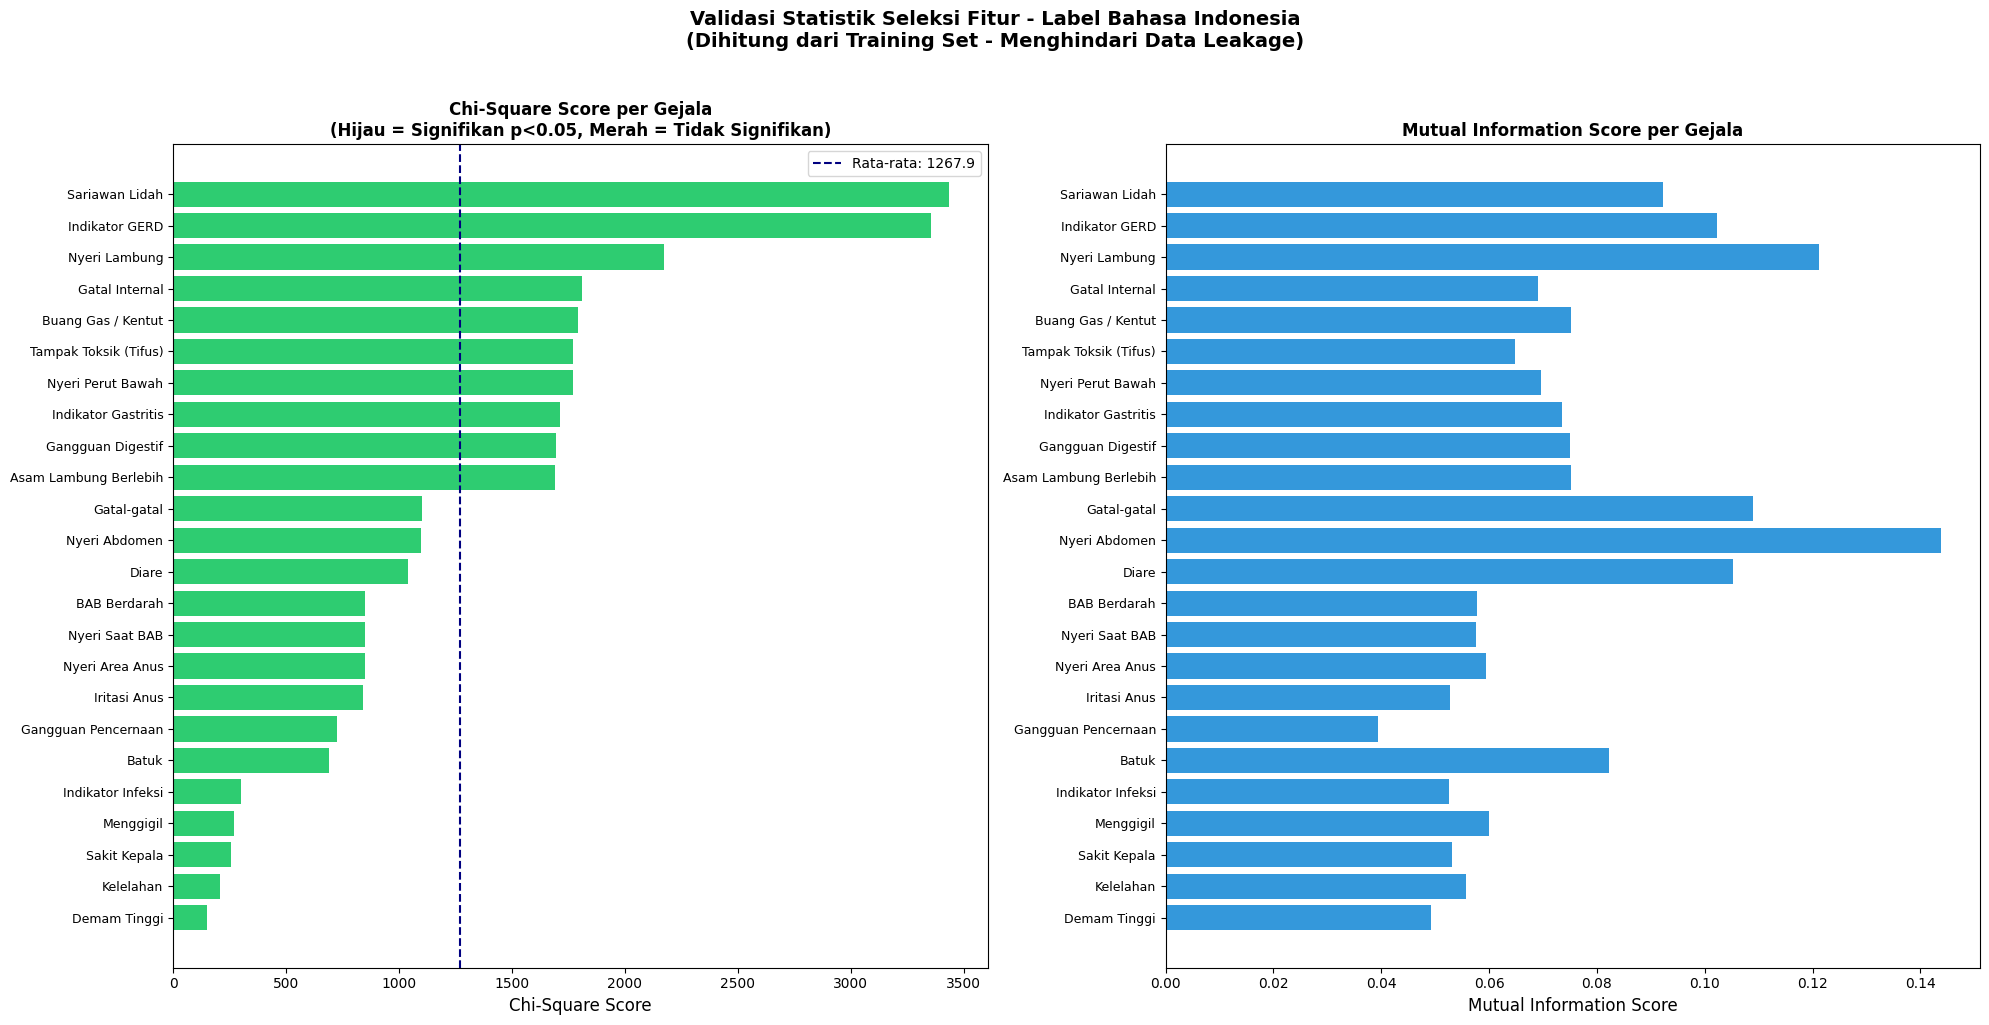

In [8]:
# === CELL 7: VALIDASI STATISTIK - CHI-SQUARE & MUTUAL INFORMATION ===
# Dijalankan pada X_train_feat untuk menghindari data leakage dari test set

chi2_scores, chi2_pvals = chi2(X_train_feat, y_train_raw)
mi_scores = mutual_info_classif(X_train_feat, y_train_raw, random_state=42)

feat_scores = pd.DataFrame({
    'Fitur'      : ALL_FEATURES,
    'Fitur_ID'   : translate(ALL_FEATURES),   # nama Bahasa Indonesia
    'Chi2_Score' : chi2_scores,
    'P_Value'    : chi2_pvals,
    'MI_Score'   : mi_scores,
}).sort_values('Chi2_Score', ascending=False).reset_index(drop=True)
feat_scores['Rank']       = range(1, len(feat_scores) + 1)
feat_scores['Signifikan'] = feat_scores['P_Value'] < 0.05

print('=' * 90)
print('  VALIDASI STATISTIK SELEKSI FITUR (Chi-Square + Mutual Information)')
print('  Label Bahasa Indonesia')
print('=' * 90)
print(f"{'No':<4} {'Gejala (Bahasa Indonesia)':<35} {'Chi2':>10} {'P-Value':>12} {'MI':>8}  Status")
print('-' * 90)
for _, row in feat_scores.iterrows():
    sig = 'Signifikan (p<0.05)' if row['Signifikan'] else 'Tidak Signifikan'
    print(f"{int(row['Rank']):<4} {row['Fitur_ID']:<35} {row['Chi2_Score']:>10.2f} "
          f"{row['P_Value']:>12.4f} {row['MI_Score']:>8.4f}  {sig}")

not_sig = feat_scores[~feat_scores['Signifikan']]['Fitur_ID'].tolist()
if not_sig:
    print(f'\nFitur tidak signifikan (p>=0.05): {not_sig}')
else:
    print(f'\nSemua {len(ALL_FEATURES)} fitur signifikan secara statistik (p<0.05)')

# === Visualisasi dengan Label Bahasa Indonesia ===
labels_id  = feat_scores['Fitur_ID'].tolist()        # label Indonesia terurut
colors_bar = ['#2ecc71' if s else '#e74c3c'
              for s in feat_scores['Signifikan']]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Chart Chi-Square
axes[0].barh(labels_id[::-1], feat_scores['Chi2_Score'][::-1],
             color=colors_bar[::-1])
axes[0].set_xlabel('Chi-Square Score', fontsize=12)
axes[0].set_title('Chi-Square Score per Gejala\n'
                  '(Hijau = Signifikan p<0.05, Merah = Tidak Signifikan)',
                  fontsize=12, fontweight='bold')
axes[0].axvline(chi2_scores.mean(), color='navy', linestyle='--',
                label=f'Rata-rata: {chi2_scores.mean():.1f}')
axes[0].legend(fontsize=10)
axes[0].tick_params(axis='y', labelsize=9)

# Chart Mutual Information
axes[1].barh(labels_id[::-1], feat_scores['MI_Score'][::-1], color='#3498db')
axes[1].set_xlabel('Mutual Information Score', fontsize=12)
axes[1].set_title('Mutual Information Score per Gejala', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle('Validasi Statistik Seleksi Fitur - Label Bahasa Indonesia\n'
             '(Dihitung dari Training Set - Menghindari Data Leakage)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('validasi_statistik_indonesia.png', dpi=150, bbox_inches='tight')
print('\nChart disimpan: validasi_statistik_indonesia.png')
plt.show()


## Tahap 4: Exploratory Data Analysis (EDA)

EDA dilakukan pada **training set** (distribusi asli, sebelum SMOTE)
untuk menghindari kebocoran informasi dari test set.

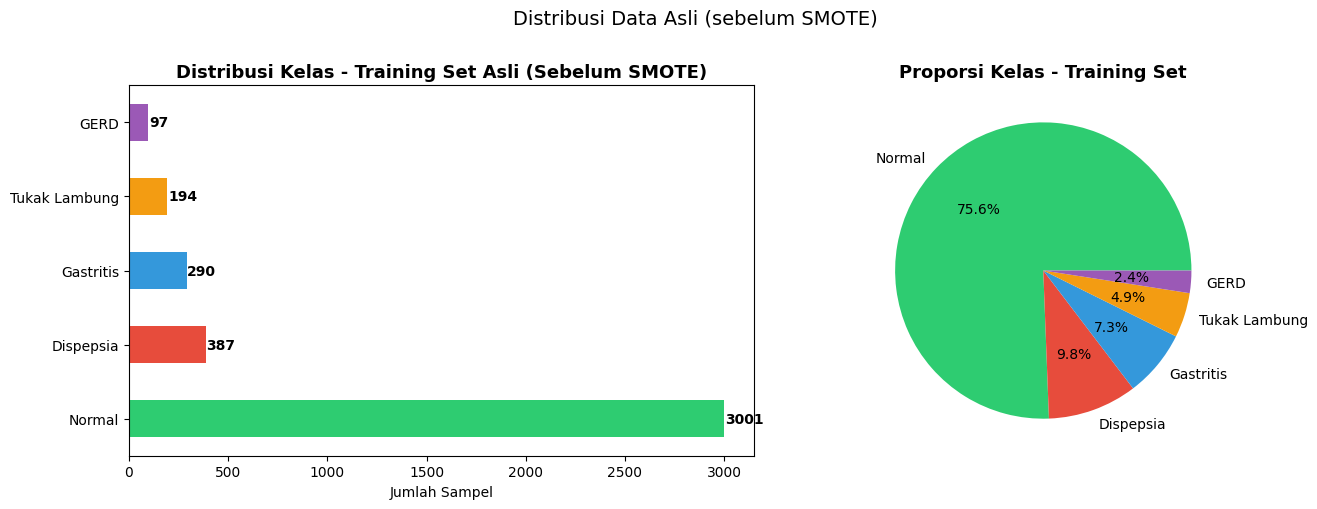

Heatmap korelasi disimpan: heatmap_korelasi_indonesia.png


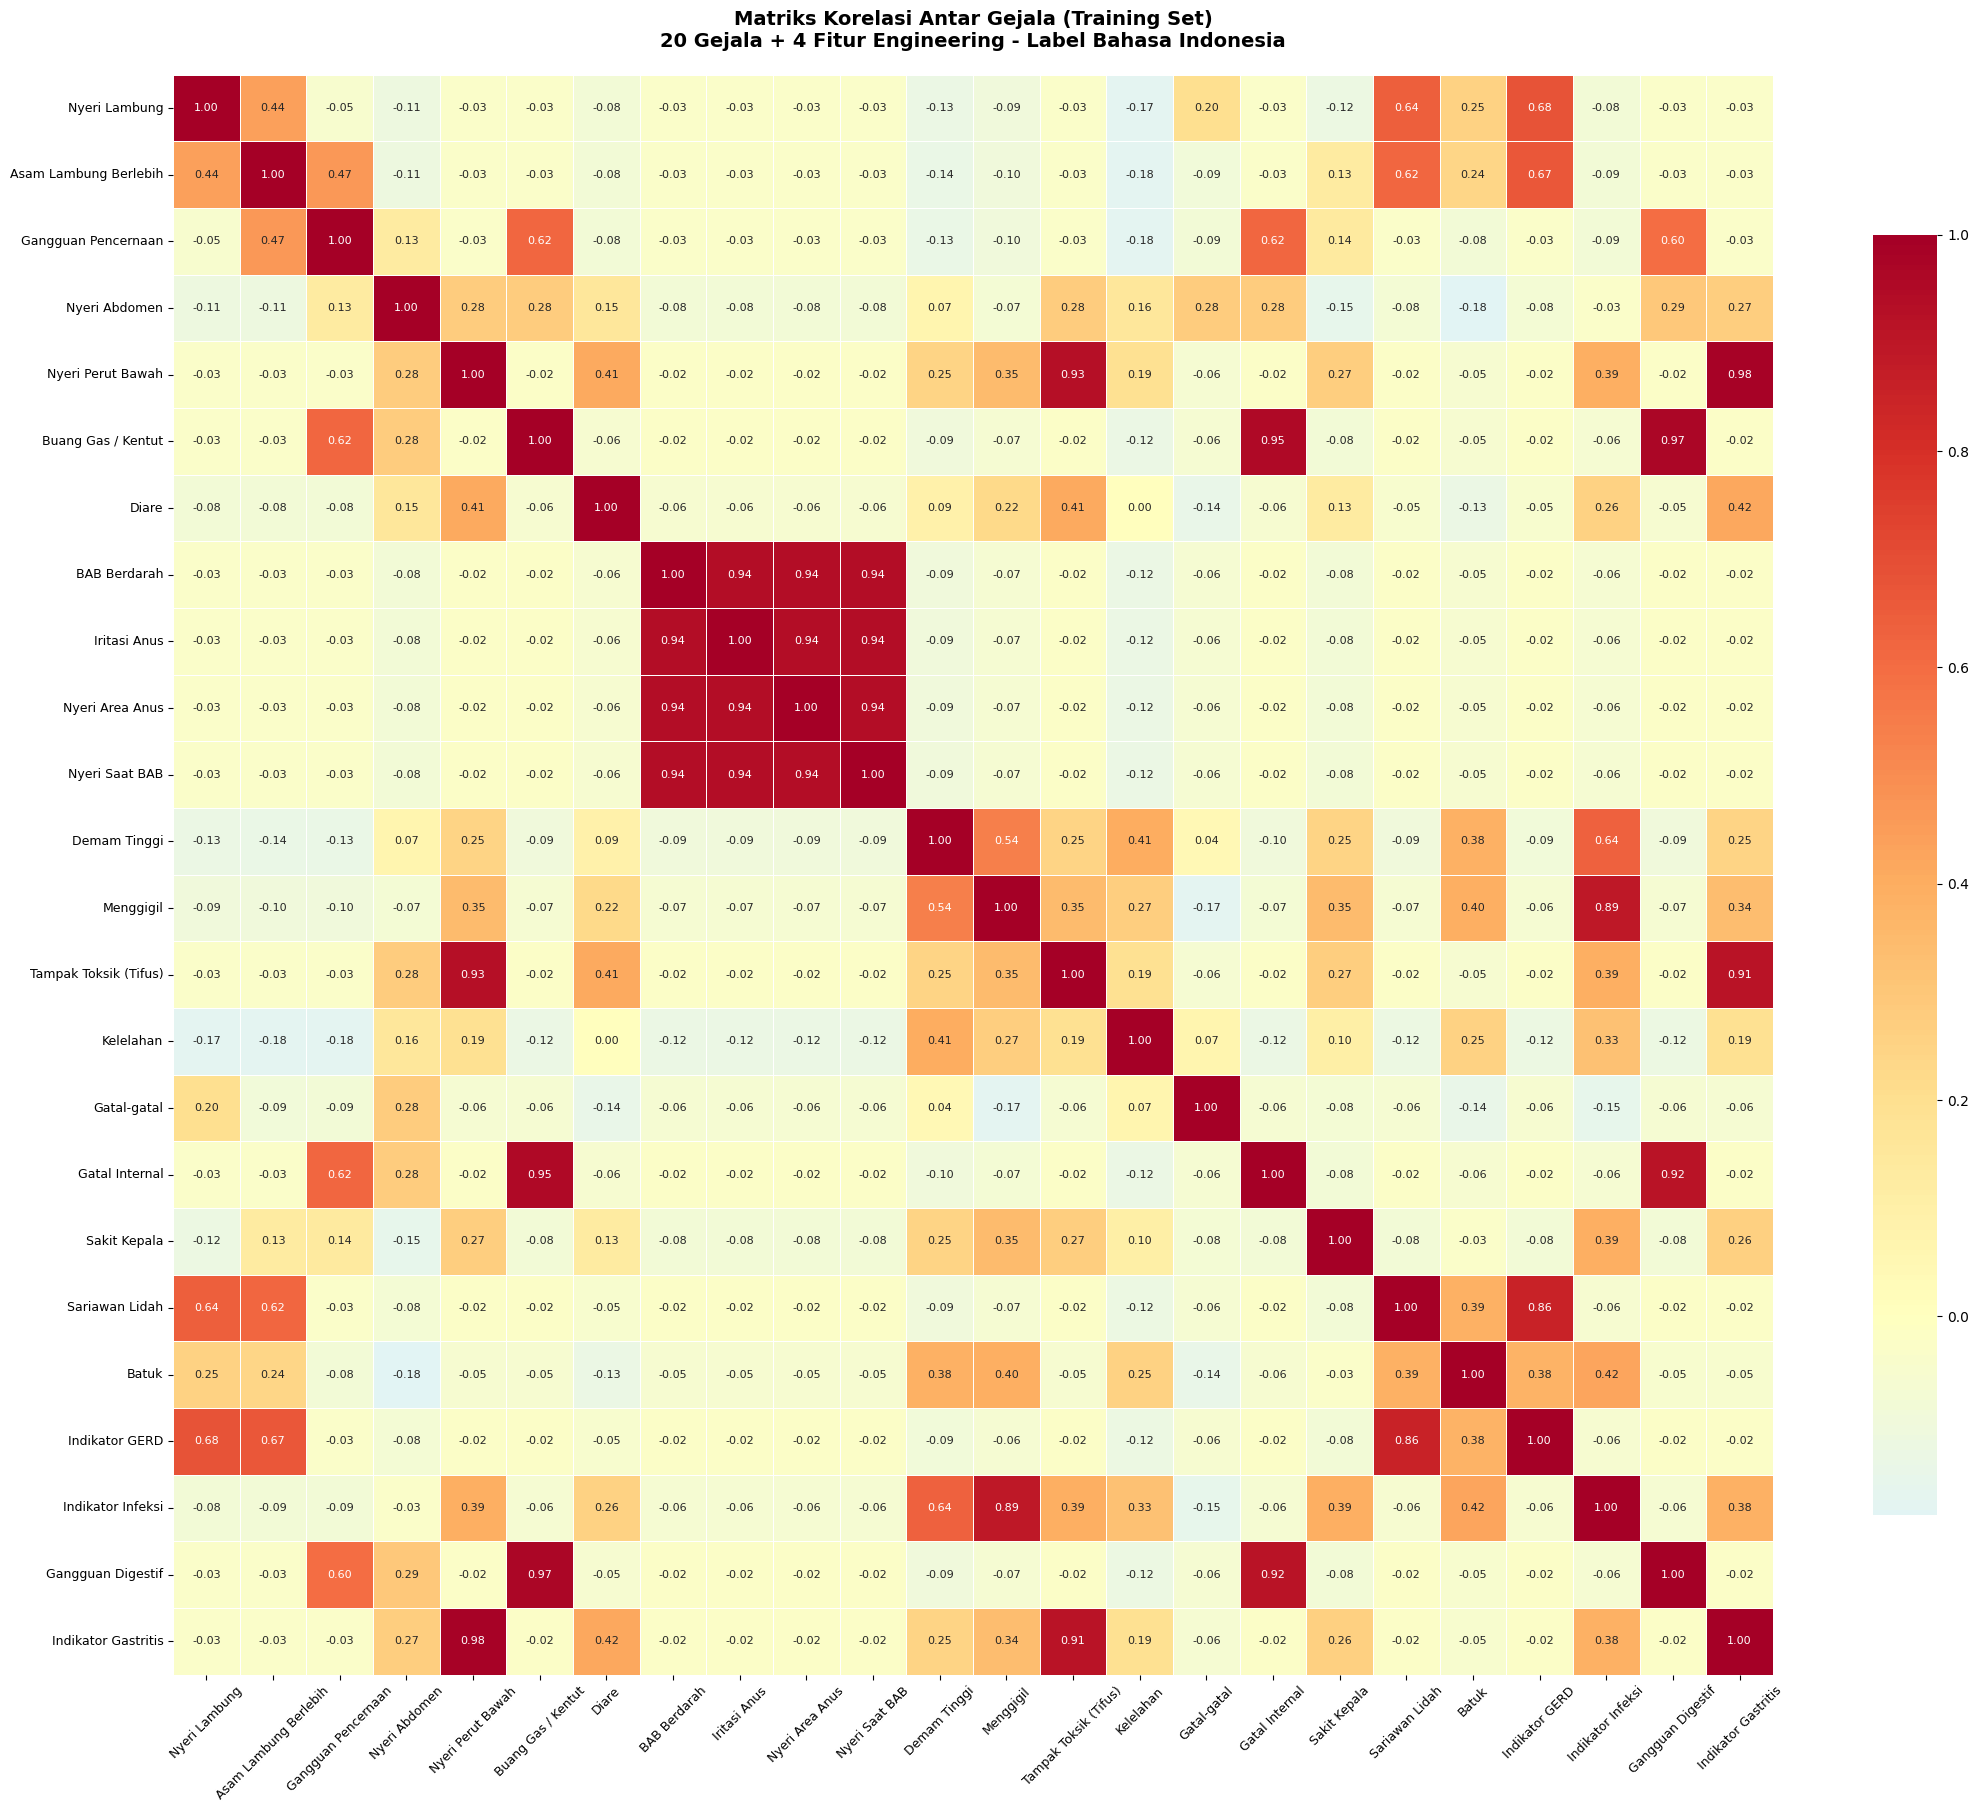

Heatmap gejala per kelas disimpan: heatmap_gejala_per_kelas.png


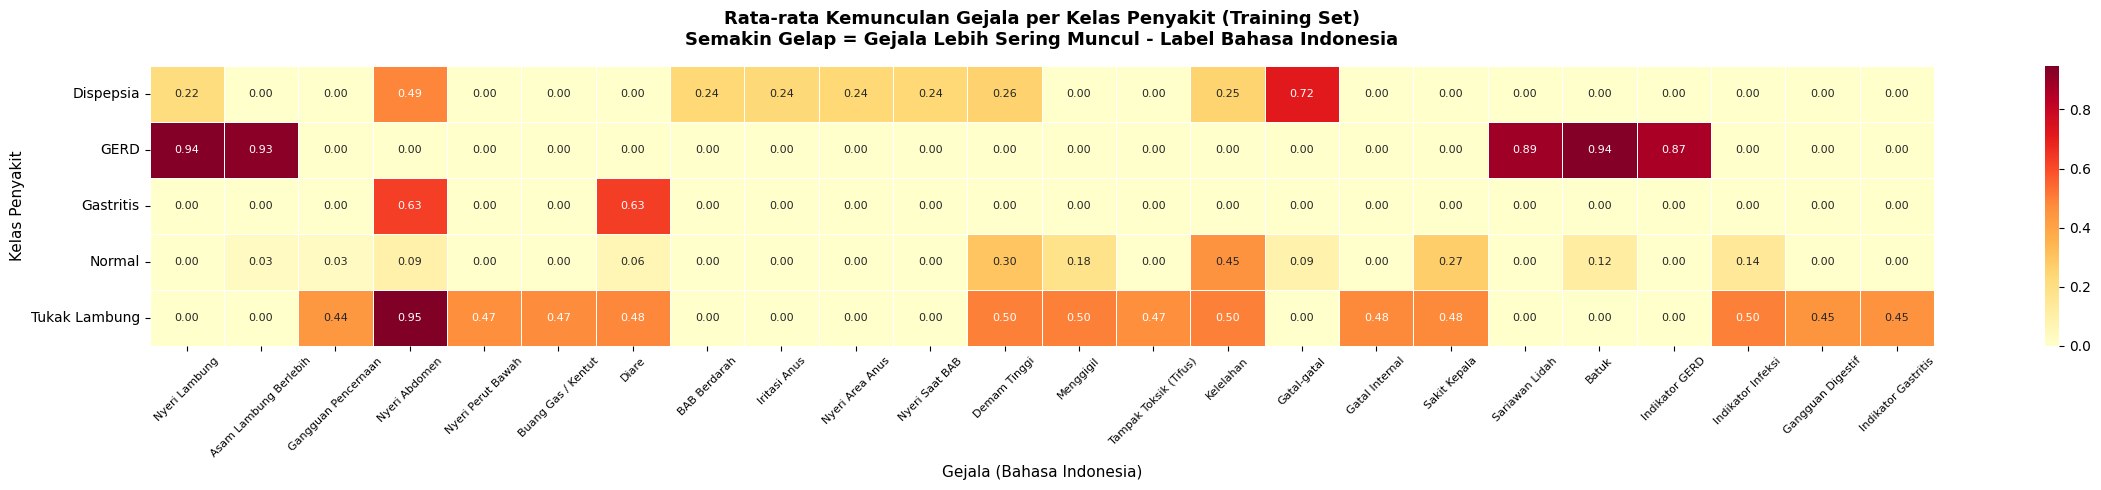

In [9]:
# === CELL 8: EDA - DISTRIBUSI KELAS + HEATMAP KORELASI (BAHASA INDONESIA) ===
colors = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6']

train_labels = pd.Series([CLASS_NAMES[y] for y in y_train_raw])
train_vc     = train_labels.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_vc.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Distribusi Kelas - Training Set Asli (Sebelum SMOTE)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Sampel')
for i, v in enumerate(train_vc.values):
    axes[0].text(v + 3, i, str(v), va='center', fontweight='bold', fontsize=10)

train_vc.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors)
axes[1].set_title('Proporsi Kelas - Training Set', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.suptitle('Distribusi Data Asli (sebelum SMOTE)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# HEATMAP KORELASI - LABEL BAHASA INDONESIA
# ============================================================
corr_df    = pd.DataFrame(X_train_feat, columns=ALL_FEATURES)
# Terjemahkan kolom ke Bahasa Indonesia menggunakan FEATURE_TRANSLATION
corr_df_id = corr_df.rename(columns=FEATURE_TRANSLATION)

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    corr_df_id.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title(
    'Matriks Korelasi Antar Gejala (Training Set)\n'
    '20 Gejala + 4 Fitur Engineering - Label Bahasa Indonesia',
    fontsize=14, fontweight='bold', pad=20
)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig('heatmap_korelasi_indonesia.png', dpi=150, bbox_inches='tight')
print('Heatmap korelasi disimpan: heatmap_korelasi_indonesia.png')
plt.show()

# ============================================================
# HEATMAP FREKUENSI GEJALA PER KELAS - LABEL BAHASA INDONESIA
# ============================================================
corr_df_kelas = corr_df.copy()
corr_df_kelas['Kelas'] = [CLASS_NAMES[y] for y in y_train_raw]
freq_kelas = corr_df_kelas.groupby('Kelas')[ALL_FEATURES].mean()
# Terjemahkan nama kolom ke Indonesia menggunakan fungsi translate()
freq_kelas.columns = translate(list(freq_kelas.columns))

fig, ax = plt.subplots(figsize=(24, 5))
sns.heatmap(
    freq_kelas,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 8}
)
ax.set_title(
    'Rata-rata Kemunculan Gejala per Kelas Penyakit (Training Set)\n'
    'Semakin Gelap = Gejala Lebih Sering Muncul - Label Bahasa Indonesia',
    fontsize=13, fontweight='bold', pad=15
)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=10, rotation=0)
ax.set_xlabel('Gejala (Bahasa Indonesia)', fontsize=11)
ax.set_ylabel('Kelas Penyakit', fontsize=11)
plt.tight_layout()
plt.savefig('heatmap_gejala_per_kelas.png', dpi=150, bbox_inches='tight')
print('Heatmap gejala per kelas disimpan: heatmap_gejala_per_kelas.png')
plt.show()


## Tahap 5: Preprocessing — Noise Augmentation + Scaling

⚡ **Optimasi:** target augmentasi diturunkan dari **2.500 → 250** per kelas. Angka 2.500 dulu dipilih ketika dataset masih memuat `Normal` dengan ribuan baris. Setelah difokuskan ke lambung, kelas sudah jauh lebih seimbang sehingga augmentasi besar justru menambah porsi data sintetis tanpa memperbaiki hasil. Pembuktiannya ada di **Tahap 8C**.

**Perbaikan kritis: SMOTE diganti Noise Augmentation**

SMOTE pada data biner menghasilkan nilai **kontinu** (interpolasi 0.3, 0.7, dll)
yang tidak ada di data asli. Ini mendistorsi GaussianNB dan BernoulliNB.

**Noise Augmentation** mempertahankan sifat biner (0/1) dengan random bit-flip:
- Setiap bit di-flip dengan probabilitas 7% (~1-2 bit dari 24 fitur)
- Output selalu biner — tidak ada nilai kontinu
- Diterapkan **hanya pada training set**, test set tetap bersih

| Kelas | Sampel Asli | Setelah Augmentasi |
|---|---|---|
| GERD | ~97 | 2500 |
| Tukak Lambung | ~194 | 2500 |
| Gastritis | ~290 | 2500 |
| Dispepsia | ~387 | 2500 |
| Normal | ~3001 | ~3001 (tidak diubah) |

In [ ]:
# === CELL 9: NOISE AUGMENTATION HANYA PADA TRAINING SET ===
# PERBAIKAN: SMOTE menghasilkan nilai KONTINU pada data biner (0/1)
# Noise augmentation mempertahankan sifat BINER data (hanya flip 0->1 atau 1->0)
print("="*65)
print("  NOISE AUGMENTATION — HANYA PADA TRAINING SET")
print("  (Menggantikan SMOTE: data tetap biner 0/1)")
print("="*65)
print(f"\nDistribusi training SEBELUM augmentasi:")
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    count = int((y_train_raw == cls_idx).sum())
    print(f"  {cls_name:20s}: {count:4d} sampel")

def noise_augment_class(X_class, n_target, flip_prob=0.07, seed=42):
    # Augmentasi biner: flip bit dengan probabilitas flip_prob
    # Output tetap 0/1, tidak ada nilai kontinu seperti SMOTE
    rng = np.random.default_rng(seed)
    needed = n_target - len(X_class)
    if needed <= 0:
        return X_class
    indices = rng.integers(0, len(X_class), size=needed)
    X_new = X_class[indices].copy().astype(float)
    mask = rng.random(X_new.shape) < flip_prob
    X_new[mask] = 1.0 - X_new[mask]  # flip: 0->1 atau 1->0
    return np.vstack([X_class, X_new])

TARGET_PER_CLASS = 250   # OPTIMASI: 2500 -> 250 (lihat Tahap 8C untuk pembuktian)

X_parts, y_parts = [], []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask_cls = (y_train_raw == cls_idx)
    X_cls = X_train_feat[mask_cls]
    n_orig = len(X_cls)
    if n_orig < TARGET_PER_CLASS:
        X_aug = noise_augment_class(X_cls, TARGET_PER_CLASS,
                                    flip_prob=0.07, seed=42 + cls_idx)
        print(f"  {cls_name:20s}: {n_orig:4d} -> {len(X_aug):5d} sampel (+{len(X_aug)-n_orig} augmented)")
    else:
        X_aug = X_cls
        print(f"  {cls_name:20s}: {n_orig:4d} sampel (tidak diaugmentasi)")
    X_parts.append(X_aug)
    y_parts.append(np.full(len(X_aug), cls_idx))

X_train_bal = np.vstack(X_parts).astype(float)
y_train_bal = np.concatenate(y_parts)

print(f"\nTotal training setelah augmentasi: {len(X_train_bal)}")
print(f"Test set: {len(X_test_feat)} sampel (TIDAK disentuh)")

# Verifikasi: semua nilai tetap biner
unique_vals = np.unique(X_train_bal)
print(f"\nVerifikasi biner: nilai unik = {unique_vals}")
assert set(unique_vals).issubset({0.0, 1.0}), "ERROR: Ada nilai non-biner!"
print("✓ Data augmentasi tetap biner 100%")

# StandardScaler untuk GaussianNB
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test_feat)

# MinMaxScaler untuk ComplementNB
mm_scaler  = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train_bal)
X_test_mm  = mm_scaler.transform(X_test_feat)

print(f"\nShape akhir:")
print(f"  X_train_bal (raw binary) : {X_train_bal.shape}")
print(f"  X_train_sc  (Standard)   : {X_train_sc.shape}")
print(f"  X_train_mm  (MinMax)     : {X_train_mm.shape}")
print(f"  X_test_feat (raw binary) : {X_test_feat.shape}")
print(f"\n✓ Scaler di-fit HANYA pada training set")
print(f"✓ Test set di-transform menggunakan parameter dari training")

## Tahap 6: Training Model Naive Bayes (Multi-Class)

⚡ **Catatan pemilihan `alpha`.** Pada dataset yang sudah difokuskan ke lambung, nilai `alpha` dari 0,001 sampai 5,0 menghasilkan F1-macro yang praktis identik (0,9958). Namun alpha kecil membuat probabilitas terlalu memuncak — satu gejala tunggal saja sudah menghasilkan keyakinan di atas 0,9, sehingga ambang pengaman gejala tunggal menjadi tidak berguna. Karena itu dipakai aturan: **di antara alpha yang skornya setara, pilih yang terbesar**, demi kalibrasi probabilitas yang sehat.

Tiga variant Naive Bayes dilatih dan dikombinasikan dalam ensemble:

| Model | Asumsi Distribusi | Cocok Untuk | Input |
|---|---|---|---|
| **BernoulliNB** | Bernoulli (0/1) | Data biner ✓ **PALING TEPAT** | Raw Binary |
| **GaussianNB** | Gaussian (kontinu) | Data kontinu | StandardScaler |
| **ComplementNB** | Complement Multinomial | Sparse/text | MinMaxScaler |

**Ensemble: BernoulliNB + GaussianNB + ComplementNB** dengan bobot optimal dari CV.

Hyperparameter dicari via **Stratified 5-Fold CV dengan scoring F1-Macro**
(lebih adil untuk kelas imbalanced).

In [ ]:
# === CELL 10: BERNOULLI NAIVE BAYES — BASELINE UTAMA ===
# BernoulliNB PALING TEPAT untuk data biner (0/1)
# Setelah noise augmentation: X_train_bal sudah biner -> binarize=0.0
# Fit pada X_train_bal (raw binary), TIDAK perlu MinMaxScaler

print("="*60)
print("  BERNOULLI NAIVE BAYES — BASELINE UTAMA")
print("="*60)
print("Data setelah noise augmentation = biner (0/1) -> binarize=0.0")
print("Fit pada X_train_bal (raw binary, tanpa scaling)\n")

alpha_grid_bnb = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 5.0]
best_f1_bnb, best_alpha_bnb = 0, 0.1
skf_bnb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Kumpulkan skor CV seluruh kandidat alpha lebih dulu
cv_alpha = {}
for alpha in alpha_grid_bnb:
    bnb = BernoulliNB(alpha=alpha, binarize=0.0)
    cv_alpha[alpha] = cross_val_score(bnb, X_train_bal, y_train_bal,
                                      cv=skf_bnb, scoring='f1_macro').mean()

# ATURAN PEMILIHAN: di antara alpha yang skornya SETARA (dalam toleransi 0.001),
# pilih alpha TERBESAR. Alasannya bukan performa, melainkan KALIBRASI.
#
# Pada dataset ini f1_macro praktis identik untuk alpha 0.001 s/d 5.0, tetapi alpha
# kecil membuat probabilitas sangat memuncak: satu gejala tunggal pun menghasilkan
# keyakinan >0.9. Akibatnya ambang pengaman `single_symptom_confidence_threshold`
# menjadi lumpuh (6 dari 6 gejala inti melewatinya). Dengan alpha besar, hanya 1 dari 6
# yang melewatinya sehingga pengaman kembali berfungsi.
#
# Ini penerapan prinsip regularisasi: di antara model yang sama baiknya, pilih yang
# paling halus.
TOLERANSI = 0.001
skor_maks = max(cv_alpha.values())
kandidat  = [a for a, s in cv_alpha.items() if s >= skor_maks - TOLERANSI]
best_alpha_bnb = max(kandidat)
best_f1_bnb    = cv_alpha[best_alpha_bnb]

print("Skor CV per alpha:")
for a in alpha_grid_bnb:
    tanda = " <- dipilih" if a == best_alpha_bnb else (" (setara)" if a in kandidat else "")
    print(f"    alpha={a:<7} CV_f1_macro={cv_alpha[a]:.4f}{tanda}")
print(f"\nAlpha setara    : {sorted(kandidat)}")
print(f"Best alpha      : {best_alpha_bnb}  (terbesar di antara yang setara -> kalibrasi terbaik)")
print(f"CV F1(macro)    : {best_f1_bnb:.4f}")

bnb_model = BernoulliNB(alpha=best_alpha_bnb, binarize=0.0)
bnb_model.fit(X_train_bal, y_train_bal)
y_pred_bnb = bnb_model.predict(X_test_feat)   # raw binary test set

print(f"\nTest Accuracy    : {accuracy_score(y_test_raw, y_pred_bnb):.4f}")
print(f"Test F1(weighted): {f1_score(y_test_raw, y_pred_bnb, average='weighted'):.4f}")
print(f"Test F1(macro)   : {f1_score(y_test_raw, y_pred_bnb, average='macro'):.4f}")

In [12]:
# === CELL 11: GAUSSIAN NAIVE BAYES ===
print("="*60)
print("  GAUSSIAN NAIVE BAYES")
print("="*60)
print("Catatan: GaussianNB mengasumsikan Gaussian — kurang ideal untuk biner")
print("Dibandingkan dengan BernoulliNB untuk keperluan analisis skripsi\n")

vs_grid = [1e-12,1e-11,1e-10,1e-9,5e-9,1e-8,5e-8,1e-7,5e-7,
           1e-6,5e-6,1e-5,5e-5,1e-4,5e-4,1e-3,5e-3,1e-2,5e-2,0.1,0.5,1.0]
best_f1_gnb, best_vs = 0, 1e-9
skf_gnb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for vs in vs_grid:
    gnb = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(gnb, X_train_sc, y_train_bal,
                             cv=skf_gnb, scoring='f1_macro')
    if scores.mean() > best_f1_gnb:
        best_f1_gnb, best_vs = scores.mean(), vs

print(f"Best var_smoothing: {best_vs}")
print(f"CV F1(weighted)   : {best_f1_gnb:.4f}")

gnb_model = GaussianNB(var_smoothing=best_vs)
gnb_model.fit(X_train_sc, y_train_bal)
y_pred_gnb = gnb_model.predict(X_test_sc)

print(f"\nTest Accuracy    : {accuracy_score(y_test_raw, y_pred_gnb):.4f}")
print(f"Test F1(weighted): {f1_score(y_test_raw, y_pred_gnb, average='weighted'):.4f}")
print(f"Test F1(macro)   : {f1_score(y_test_raw, y_pred_gnb, average='macro'):.4f}")

  GAUSSIAN NAIVE BAYES
Catatan: GaussianNB mengasumsikan Gaussian — kurang ideal untuk biner
Dibandingkan dengan BernoulliNB untuk keperluan analisis skripsi

Best var_smoothing: 0.5
CV F1(weighted)   : 0.8012

Test Accuracy    : 0.8761
Test F1(weighted): 0.8462
Test F1(macro)   : 0.7602


In [13]:
# === CELL 12: COMPLEMENT NAIVE BAYES ===
print("="*60)
print("  COMPLEMENT NAIVE BAYES")
print("="*60)

alpha_grid_cnb = [0.001,0.005,0.01,0.05,0.1,0.2,0.3,0.5,0.7,
                  1.0,1.5,2.0,3.0,5.0,7.0,10.0]
best_f1_cnb, best_alpha_cnb = 0, 1.0
skf_cnb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alpha_grid_cnb:
    cnb = ComplementNB(alpha=alpha)
    scores = cross_val_score(cnb, X_train_mm, y_train_bal,
                             cv=skf_cnb, scoring='f1_macro')
    if scores.mean() > best_f1_cnb:
        best_f1_cnb, best_alpha_cnb = scores.mean(), alpha

print(f"Best alpha       : {best_alpha_cnb}")
print(f"CV F1(weighted)  : {best_f1_cnb:.4f}")

cnb_model = ComplementNB(alpha=best_alpha_cnb)
cnb_model.fit(X_train_mm, y_train_bal)
y_pred_cnb = cnb_model.predict(X_test_mm)

print(f"\nTest Accuracy    : {accuracy_score(y_test_raw, y_pred_cnb):.4f}")
print(f"Test F1(weighted): {f1_score(y_test_raw, y_pred_cnb, average='weighted'):.4f}")
print(f"Test F1(macro)   : {f1_score(y_test_raw, y_pred_cnb, average='macro'):.4f}")

  COMPLEMENT NAIVE BAYES
Best alpha       : 10.0
CV F1(weighted)  : 0.7213

Test Accuracy    : 0.6354
Test F1(weighted): 0.6703
Test F1(macro)   : 0.6491


In [14]:
# === CELL 13: OPTIMIZED 3-MODEL ENSEMBLE (BNB + GNB + CNB) ===
print("="*65)
print("  OPTIMASI BOBOT ENSEMBLE — 3 MODEL (BNB + GNB + CNB)")
print("="*65)
print("Cari w1,w2,w3 (sum=1.0) yang memaksimalkan F1-macro pada CV\n")

skf_ens = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_w1, best_w2, best_w3 = 0.4, 0.4, 0.2
best_f1_ens = 0

weight_options = [0.1, 0.2, 0.3, 0.4, 0.5]
for w1 in weight_options:
    for w2 in weight_options:
        w3 = round(1.0 - w1 - w2, 1)
        if w3 < 0.1 or w3 > 0.8:
            continue
        fold_f1s = []
        for tr_idx, val_idx in skf_ens.split(X_train_bal, y_train_bal):
            ens_p = w1 * bnb_model.predict_proba(X_train_bal[val_idx]) + \
                    w2 * gnb_model.predict_proba(X_train_sc[val_idx]) + \
                    w3 * cnb_model.predict_proba(X_train_mm[val_idx])
            fold_f1s.append(f1_score(y_train_bal[val_idx],
                                     ens_p.argmax(axis=1), average='macro'))
        avg = np.mean(fold_f1s)
        if avg > best_f1_ens:
            best_f1_ens, best_w1, best_w2, best_w3 = avg, w1, w2, w3

print(f"Bobot optimal:")
print(f"  BernoulliNB  (w1) = {best_w1:.2f}")
print(f"  GaussianNB   (w2) = {best_w2:.2f}")
print(f"  ComplementNB (w3) = {best_w3:.2f}")
print(f"CV F1(macro) training: {best_f1_ens:.4f}")

bnb_proba      = bnb_model.predict_proba(X_test_feat)
gnb_proba      = gnb_model.predict_proba(X_test_sc)
cnb_proba      = cnb_model.predict_proba(X_test_mm)
ensemble_proba = best_w1 * bnb_proba + best_w2 * gnb_proba + best_w3 * cnb_proba
y_pred_ensemble = ensemble_proba.argmax(axis=1)

print(f"\nEnsemble Test Accuracy    : {accuracy_score(y_test_raw, y_pred_ensemble):.4f}")
print(f"Ensemble Test F1(weighted): {f1_score(y_test_raw, y_pred_ensemble, average='weighted'):.4f}")
print(f"Ensemble Test F1(macro)   : {f1_score(y_test_raw, y_pred_ensemble, average='macro'):.4f}")

  OPTIMASI BOBOT ENSEMBLE — 3 MODEL (BNB + GNB + CNB)
Cari w1,w2,w3 (sum=1.0) yang memaksimalkan F1-macro pada CV

Bobot optimal:
  BernoulliNB  (w1) = 0.50
  GaussianNB   (w2) = 0.10
  ComplementNB (w3) = 0.40
CV F1(macro) training: 0.9192

Ensemble Test Accuracy    : 0.9355
Ensemble Test F1(weighted): 0.9401
Ensemble Test F1(macro)   : 0.9279


## Tahap 7: Evaluasi Model (5 Kelas)

Evaluasi dilakukan pada **test set distribusi asli** (tidak di-SMOTE).
Ini memberikan gambaran performa yang lebih jujur dibanding versi sebelumnya.

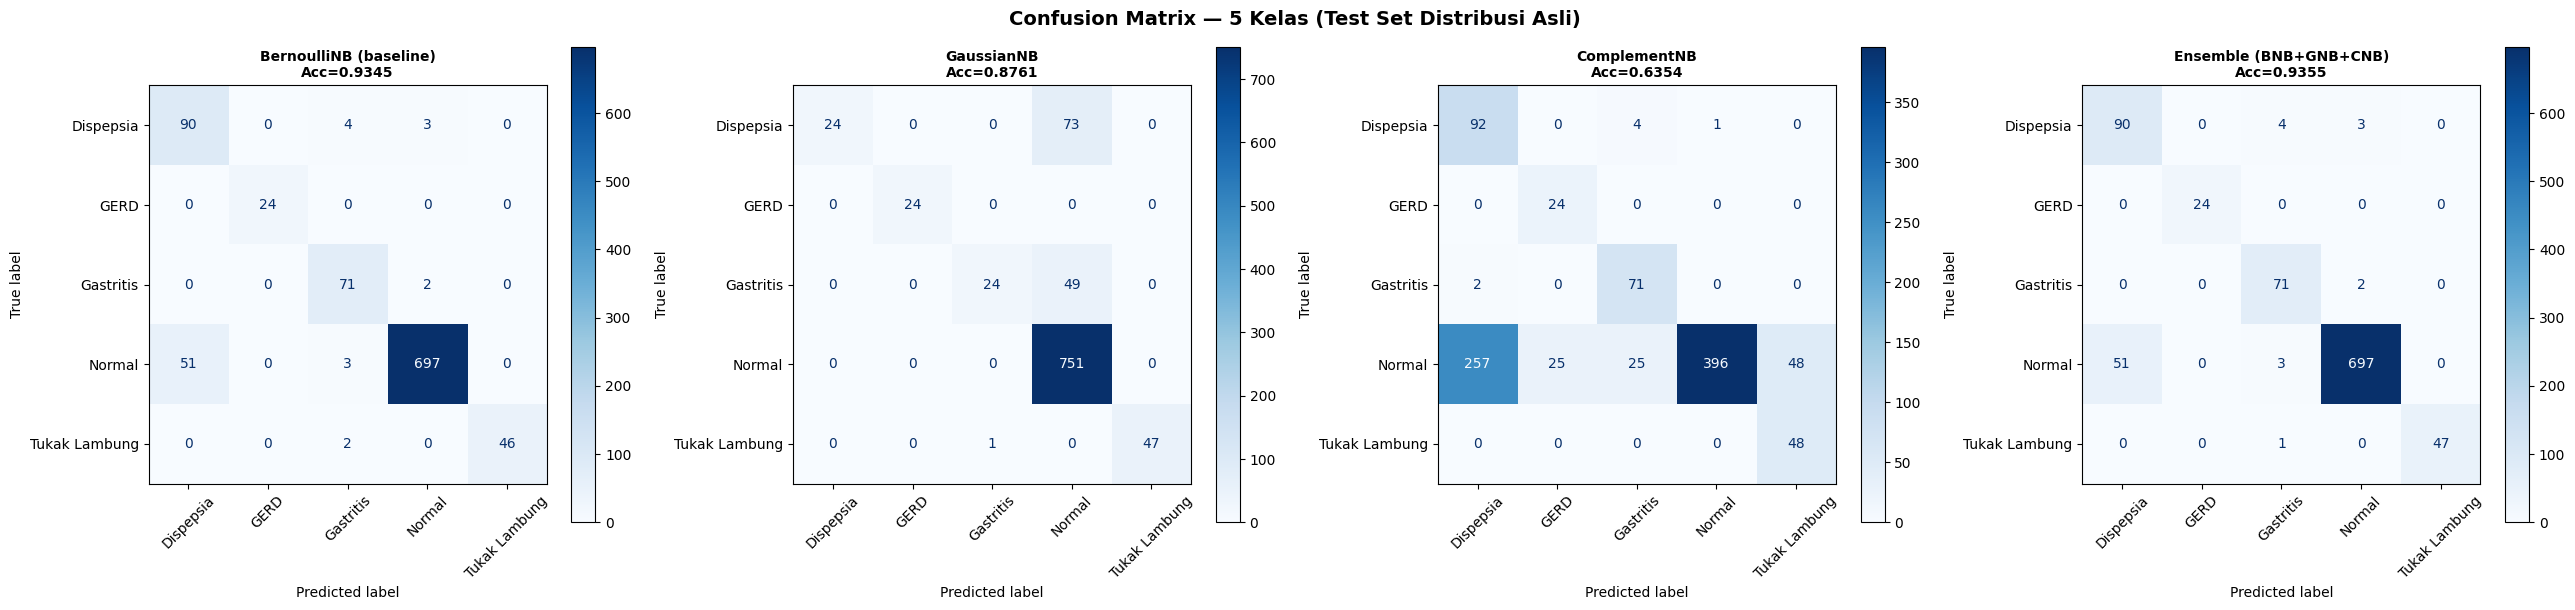

In [15]:
# === CELL 14: CONFUSION MATRIX — 4 MODEL ===
all_models = {
    'BernoulliNB (baseline)': y_pred_bnb,
    'GaussianNB'            : y_pred_gnb,
    'ComplementNB'          : y_pred_cnb,
    'Ensemble (BNB+GNB+CNB)'    : y_pred_ensemble,
}
fig, axes = plt.subplots(1, 4, figsize=(26, 6))
colors_cm = ['#8e44ad','#e74c3c','#3498db','#2ecc71']
for idx, (name, yp) in enumerate(all_models.items()):
    cm = confusion_matrix(y_test_raw, yp)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=axes[idx], cmap='Blues', xticks_rotation=45)
    acc = accuracy_score(y_test_raw, yp)
    axes[idx].set_title(f'{name}\nAcc={acc:.4f}', fontweight='bold', fontsize=10)
plt.suptitle('Confusion Matrix — 5 Kelas (Test Set Distribusi Asli)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [16]:
# === CELL 15: CLASSIFICATION REPORT PER KELAS ===
print("="*70)
print("  CLASSIFICATION REPORT PER KELAS — 5 KELAS DIAGNOSIS")
print("  (Test set = distribusi asli, tanpa SMOTE)")
print("="*70)
for name, yp in all_models.items():
    print(f"\n{'─'*60}")
    print(f"  Model: {name}")
    print(f"{'─'*60}")
    print(classification_report(y_test_raw, yp, target_names=CLASS_NAMES, digits=4))
    # Soroti F1 per kelas untuk kelas minoritas
    from sklearn.metrics import f1_score as f1s
    per_class_f1 = f1s(y_test_raw, yp, average=None, labels=list(range(len(CLASS_NAMES))))
    print(f"  F1 per kelas (untuk analisis kelas minoritas):")
    for cls_name, f1_val in zip(CLASS_NAMES, per_class_f1):
        warn = ' <-- Perlu perhatian' if f1_val < 0.70 else ''
        print(f"    {cls_name:20s}: {f1_val:.4f}{warn}")

  CLASSIFICATION REPORT PER KELAS — 5 KELAS DIAGNOSIS
  (Test set = distribusi asli, tanpa SMOTE)

────────────────────────────────────────────────────────────
  Model: BernoulliNB (baseline)
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

    Dispepsia     0.6383    0.9278    0.7563        97
         GERD     1.0000    1.0000    1.0000        24
    Gastritis     0.8875    0.9726    0.9281        73
       Normal     0.9929    0.9281    0.9594       751
Tukak Lambung     1.0000    0.9583    0.9787        48

     accuracy                         0.9345       993
    macro avg     0.9037    0.9574    0.9245       993
 weighted avg     0.9510    0.9345    0.9392       993

  F1 per kelas (untuk analisis kelas minoritas):
    Dispepsia           : 0.7563
    GERD                : 1.0000
    Gastritis           : 0.9281
    Normal              : 0.9594
    Tukak Lambung       : 0.9787

──────────────────────────────────

In [17]:
# === CELL 16: CROSS-VALIDATION 5-FOLD + OVERFITTING DETECTION ===
print("="*65)
print("  STRATIFIED 5-FOLD CV + DETEKSI OVERFITTING")
print("="*65)
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_configs = [
    ('BernoulliNB', BernoulliNB(alpha=best_alpha_bnb, binarize=0.0), X_train_bal),
    ('GaussianNB',  GaussianNB(var_smoothing=best_vs),               X_train_sc),
    ('ComplementNB',ComplementNB(alpha=best_alpha_cnb),              X_train_mm),
]
for name, mdl, Xcv in cv_configs:
    scores_w = cross_val_score(mdl, Xcv, y_train_bal, cv=skf_cv, scoring='f1_weighted')
    scores_m = cross_val_score(mdl, Xcv, y_train_bal, cv=skf_cv, scoring='f1_macro')
    print(f"\n{name}:")
    print(f"  CV F1(weighted): {scores_w.mean():.4f} \u00b1 {scores_w.std():.4f}")
    print(f"  CV F1(macro)   : {scores_m.mean():.4f} \u00b1 {scores_m.std():.4f}")
    print(f"  Per fold (W)   : {[f'{s:.4f}' for s in scores_w]}")

print("\n" + "="*65)
print("  DETEKSI OVERFITTING — Train Score vs Test Score")
print("="*65)
# Xte dihapus dari tuple (tidak dipakai — test score pakai y_pred_* yang sudah ada)
overfitting_data = [
    ('BernoulliNB', BernoulliNB(alpha=best_alpha_bnb, binarize=0.0), X_train_bal, y_pred_bnb),
    ('GaussianNB',  GaussianNB(var_smoothing=best_vs),               X_train_sc, y_pred_gnb),
    ('ComplementNB',ComplementNB(alpha=best_alpha_cnb),              X_train_mm, y_pred_cnb),
]
for name, mdl, Xtr, yp in overfitting_data:
    mdl_fit  = mdl.fit(Xtr, y_train_bal)
    train_f1 = f1_score(y_train_bal, mdl_fit.predict(Xtr), average='weighted')
    test_f1  = f1_score(y_test_raw,  yp,                   average='weighted')
    gap      = abs(train_f1 - test_f1)
    status   = ('OK (Tidak Overfit)' if gap < 0.05
                else ('PERHATIAN (Ringan)' if gap < 0.10
                      else 'PERINGATAN (Berat)'))
    print(f"\n  {name}:")
    print(f"    Train F1(weighted): {train_f1:.4f}")
    print(f"    Test F1(weighted) : {test_f1:.4f}")
    print(f"    Gap               : {gap:.4f} \u2192 {status}")

  STRATIFIED 5-FOLD CV + DETEKSI OVERFITTING

BernoulliNB:
  CV F1(weighted): 0.9220 ± 0.0094
  CV F1(macro)   : 0.9216 ± 0.0093
  Per fold (W)   : ['0.9077', '0.9244', '0.9338', '0.9153', '0.9287']

GaussianNB:
  CV F1(weighted): 0.7992 ± 0.0071
  CV F1(macro)   : 0.8012 ± 0.0070
  Per fold (W)   : ['0.8003', '0.8094', '0.7940', '0.7891', '0.8032']

ComplementNB:
  CV F1(weighted): 0.7196 ± 0.0123
  CV F1(macro)   : 0.7213 ± 0.0120
  Per fold (W)   : ['0.7140', '0.7168', '0.7362', '0.7010', '0.7297']

  DETEKSI OVERFITTING — Train Score vs Test Score

  BernoulliNB:
    Train F1(weighted): 0.9220
    Test F1(weighted) : 0.9392
    Gap               : 0.0172 → OK (Tidak Overfit)

  GaussianNB:
    Train F1(weighted): 0.8018
    Test F1(weighted) : 0.8462
    Gap               : 0.0445 → OK (Tidak Overfit)

  ComplementNB:
    Train F1(weighted): 0.7188
    Test F1(weighted) : 0.6703
    Gap               : 0.0485 → OK (Tidak Overfit)


Chart disimpan: perbandingan_model.png


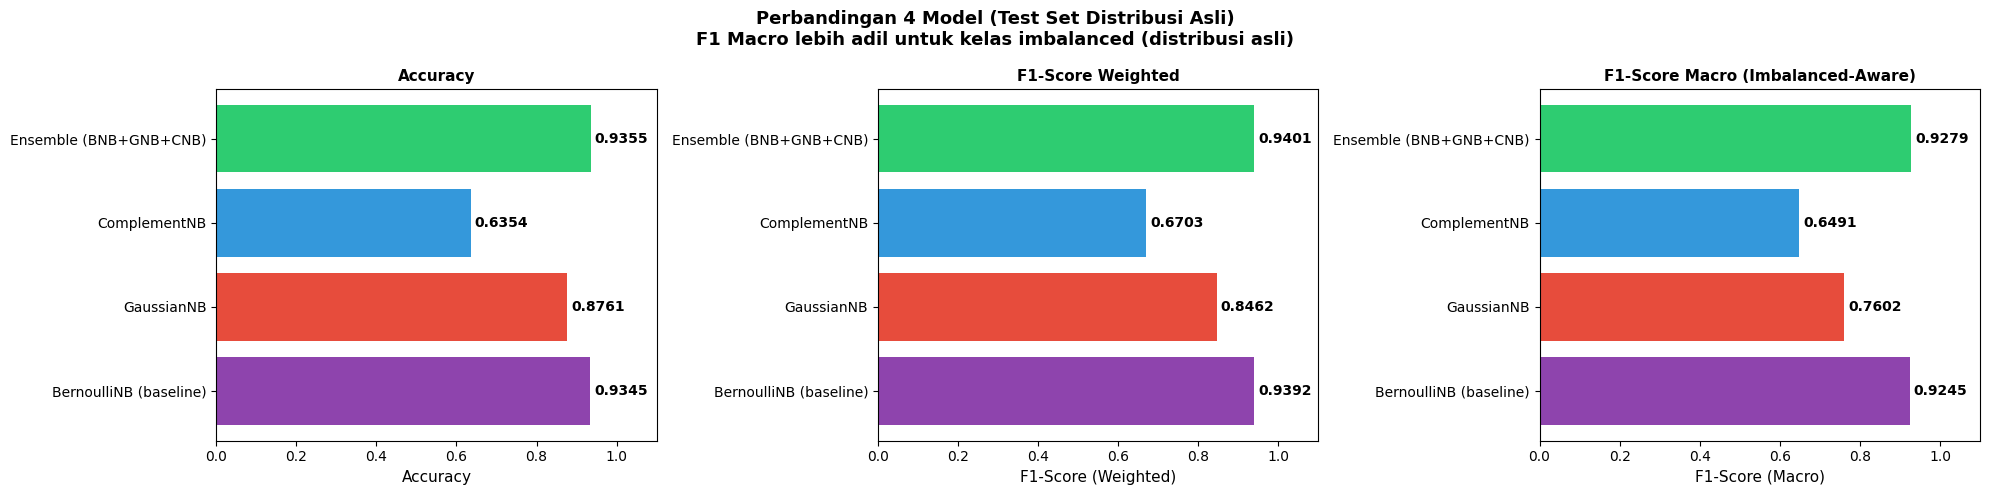


  TABEL RINGKASAN PERFORMA MODEL
Model                       Accuracy  F1 Weighted   F1 Macro
----------------------------------------------------------------------
  BernoulliNB (baseline)      0.9345       0.9392     0.9245 <-- Baseline
  GaussianNB                  0.8761       0.8462     0.7602
  ComplementNB                0.6354       0.6703     0.6491
  Ensemble (BNB+GNB+CNB)      0.9355       0.9401     0.9279 <-- Ensemble

Catatan: F1 Macro = rata-rata F1 per kelas tanpa memperhitungkan proporsi
         lebih tepat untuk menilai performa pada kelas-kelas minoritas


In [18]:
# === CELL 17: PERBANDINGAN VISUAL 4 MODEL ===
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
names       = list(all_models.keys())
bar_colors  = ['#8e44ad','#e74c3c','#3498db','#2ecc71']

accs   = [accuracy_score(y_test_raw, all_models[n]) for n in names]
f1s_w  = [f1_score(y_test_raw, all_models[n], average='weighted') for n in names]
f1s_m  = [f1_score(y_test_raw, all_models[n], average='macro')    for n in names]

for ax, vals, title, xlabel in zip(
        axes,
        [accs, f1s_w, f1s_m],
        ['Accuracy', 'F1-Score Weighted', 'F1-Score Macro (Imbalanced-Aware)'],
        ['Accuracy', 'F1-Score (Weighted)', 'F1-Score (Macro)']):
    bars = ax.barh(names, vals, color=bar_colors)
    ax.set_xlim(0, 1.10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=11)
    for b, v in zip(bars, vals):
        ax.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2,
                f'{v:.4f}', va='center', fontweight='bold', fontsize=10)

plt.suptitle(
    'Perbandingan 4 Model (Test Set Distribusi Asli)\n'
    'F1 Macro lebih adil untuk kelas imbalanced (distribusi asli)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
print('Chart disimpan: perbandingan_model.png')
plt.show()

# Tabel ringkasan
print()
print('='*70)
print('  TABEL RINGKASAN PERFORMA MODEL')
print('='*70)
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Weighted':>12} {'F1 Macro':>10}")
print('-'*70)
for name, yp in all_models.items():
    acc  = accuracy_score(y_test_raw, yp)
    f1w  = f1_score(y_test_raw, yp, average='weighted')
    f1m  = f1_score(y_test_raw, yp, average='macro')
    mark = ' <-- Ensemble' if 'Ensemble' in name else (
           ' <-- Baseline' if 'Bernoulli' in name else '')
    print(f"  {name:<23} {acc:>10.4f} {f1w:>12.4f} {f1m:>10.4f}{mark}")
print()
print('Catatan: F1 Macro = rata-rata F1 per kelas tanpa memperhitungkan proporsi')
print('         lebih tepat untuk menilai performa pada kelas-kelas minoritas')

## Tahap 8: Study Case — Simulasi Pasien (5 Kelas)

**Perbaikan dibanding versi sebelumnya:**
- Ditambahkan **confidence threshold 60%**
- Jika model tidak yakin (confidence < 60%), sistem menolak memberikan diagnosis
- Ditambahkan disclaimer klinis di setiap output prediksi

In [19]:
# === CELL 18: STUDY CASE DENGAN CONFIDENCE THRESHOLD ===
CONFIDENCE_THRESHOLD = 0.60   # tolak diagnosis jika confidence < 60%

def diagnosa_5kelas(raw_symptoms, patient_name='Pasien',
                    threshold=CONFIDENCE_THRESHOLD):
    '''
    Diagnosa 5 kelas dengan confidence threshold.
    raw_symptoms : dict {nama_fitur_inggris: 0/1}
    Ensemble: BernoulliNB + GaussianNB + ComplementNB (3-model)
    '''
    X_p = np.zeros((1, len(symptom_cols)))
    active = []
    for i, col in enumerate(symptom_cols):
        if raw_symptoms.get(col, 0) == 1:
            X_p[0, i] = 1
            active.append(FEATURE_TRANSLATION.get(col, col))

    X_p_feat = add_engineered_features(X_p, symptom_cols)
    X_p_sc   = scaler.transform(X_p_feat)
    X_p_mm   = mm_scaler.transform(X_p_feat)

    bnb_prob  = bnb_model.predict_proba(X_p_feat)[0]   # raw binary
    gnb_prob  = gnb_model.predict_proba(X_p_sc)[0]
    cnb_prob  = cnb_model.predict_proba(X_p_mm)[0]
    ens_prob  = best_w1 * bnb_prob + best_w2 * gnb_prob + best_w3 * cnb_prob

    pred_idx   = int(ens_prob.argmax())
    pred_label = CLASS_NAMES[pred_idx]
    conf       = float(ens_prob[pred_idx])

    print(f"\n{'='*60}")
    print(f"  {patient_name}")
    print(f"{'='*60}")
    print(f"  Gejala aktif ({len(active)}): {', '.join(active) if active else 'Tidak ada'}")

    if conf < threshold:
        print(f"\n  TIDAK DAPAT MENDIAGNOSIS")
        print(f"  Confidence tertinggi : {conf*100:.1f}%")
        print(f"  Threshold minimum    : {threshold*100:.0f}%")
        print(f"  Rekomendasi: Lengkapi gejala atau konsultasikan ke dokter")
        result = 'Tidak dapat mendiagnosis'
    else:
        print(f"\n  >>> DIAGNOSIS   : {pred_label}")
        print(f"  >>> Confidence  : {conf*100:.1f}%")
        result = pred_label

    print(f"\n  Probabilitas per kelas (Ensemble BNB+GNB+CNB):")
    for j, cls in enumerate(CLASS_NAMES):
        bar    = '#' * int(ens_prob[j] * 30)
        marker = ' <- PREDIKSI' if j == pred_idx else ''
        print(f"    {cls:20s}: {ens_prob[j]*100:6.2f}% {bar}{marker}")

    print(f"\n  DISCLAIMER: Hasil ini BUKAN diagnosis medis resmi.")
    print(f"     Selalu konsultasikan dengan dokter yang berkompeten.")
    return result


print("="*60)
print("  STUDY CASE — DIAGNOSA 5 KELAS")
print(f"  Ensemble: BNB (w={best_w1}) + GNB (w={best_w2}) + CNB (w={best_w3})")
print(f"  Confidence Threshold: {CONFIDENCE_THRESHOLD*100:.0f}%")
print("="*60)

# Case 1: GERD
r1 = diagnosa_5kelas({'acidity':1,'stomach_pain':1,'indigestion':1,
                      'headache':1,'cough':1}, 'Case 1: Suspek GERD')

# Case 2: Tukak Lambung
r2 = diagnosa_5kelas({'abdominal_pain':1,'bloody_stool':1,'fatigue':1,
                      'belly_pain':1,'high_fever':1,'chills':1},
                     'Case 2: Suspek Tukak Lambung')

# Case 3: Gastritis
r3 = diagnosa_5kelas({'diarrhoea':1,'belly_pain':1,'passage_of_gases':1,
                      'fatigue':1,'abdominal_pain':1,'chills':1},
                     'Case 3: Suspek Gastritis')

# Case 4: Dispepsia
r4 = diagnosa_5kelas({'indigestion':1,'abdominal_pain':1,'passage_of_gases':1,
                      'itching':1}, 'Case 4: Suspek Dispepsia')

# Case 5: Gejala minimal
r5 = diagnosa_5kelas({'cough':1}, 'Case 5: Gejala Minimal (1 gejala)')

print("\n" + "="*60)
print("  RINGKASAN STUDY CASE")
print("="*60)
cases = [('Case 1 (GERD)', r1), ('Case 2 (Tukak)', r2),
         ('Case 3 (Gastritis)', r3), ('Case 4 (Dispepsia)', r4),
         ('Case 5 (Normal/Ambig)', r5)]
for name, res in cases:
    mark = 'OK' if res != 'Tidak dapat mendiagnosis' else 'THRESHOLD'
    print(f"  [{mark}] {name:25s}: {res}")

  STUDY CASE — DIAGNOSA 5 KELAS
  Ensemble: BNB (w=0.5) + GNB (w=0.1) + CNB (w=0.4)
  Confidence Threshold: 60%

  Case 1: Suspek GERD
  Gejala aktif (5): Nyeri Lambung, Asam Lambung Berlebih, Gangguan Pencernaan, Sakit Kepala, Batuk

  >>> DIAGNOSIS   : GERD
  >>> Confidence  : 98.5%

  Probabilitas per kelas (Ensemble BNB+GNB+CNB):
    Dispepsia           :   0.29% 
    GERD                :  98.49% ############################# <- PREDIKSI
    Gastritis           :   0.39% 
    Normal              :   0.55% 
    Tukak Lambung       :   0.28% 

  DISCLAIMER: Hasil ini BUKAN diagnosis medis resmi.
     Selalu konsultasikan dengan dokter yang berkompeten.

  Case 2: Suspek Tukak Lambung
  Gejala aktif (6): Nyeri Abdomen, Nyeri Perut Bawah, BAB Berdarah, Demam Tinggi, Menggigil, Kelelahan

  >>> DIAGNOSIS   : Tukak Lambung
  >>> Confidence  : 77.3%

  Probabilitas per kelas (Ensemble BNB+GNB+CNB):
    Dispepsia           :   8.77% ##
    GERD                :   1.04% 
    Gastritis     

## Tahap 8B: 🆕 REVISI 1 — Perbandingan Rasio Split 80:20 vs 70:30

**Revisi client:** *"Buatkan perbandingan data split antara 80:20 dan 70:30, buatkan
perbandingan mana yang baik, dan buatkan kelemahan serta kekurangannya juga."*

### Cara pengujian

Seluruh pipeline (split → feature engineering → augmentasi → tuning `alpha` → training →
evaluasi) dibungkus dalam **satu fungsi**, sehingga satu-satunya hal yang berbeda antara
kedua skenario adalah `test_size`. Pengujian diulang **10 seed** agar selisih kecil tidak
tertukar dengan kebetulan, lalu diuji dengan **Wilcoxon signed-rank** (berpasangan, tidak
mengasumsikan distribusi normal).

### Analogi sederhana

Bayangkan murid belajar. Bahan belajar lebih banyak (80%) membuat murid sedikit lebih
pintar, tetapi soal ujiannya jadi lebih sedikit sehingga nilainya kurang dapat dipercaya.
Sebaliknya 70:30 memberi soal ujian lebih banyak — nilainya lebih jujur, walau muridnya
sedikit kurang terlatih.

In [ ]:
# === CELL 17B: REVISI 1 — PERBANDINGAN SPLIT 80:20 vs 70:30 ===
def evaluasi_split(test_size, seed):
    # Pipeline lengkap; HANYA test_size yang berbeda antar skenario.
    Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
        X_all, y_all, test_size=test_size, random_state=seed, stratify=y_all)

    Xtr_f = add_engineered_features(Xtr_r, symptom_cols)
    Xte_f = add_engineered_features(Xte_r, symptom_cols)

    Xp, yp = [], []
    for ci in range(len(CLASS_NAMES)):
        Xc = Xtr_f[ytr_r == ci]
        Xa = (noise_augment_class(Xc, TARGET_PER_CLASS, flip_prob=0.07, seed=seed + ci)
              if len(Xc) < TARGET_PER_CLASS else Xc)
        Xp.append(Xa); yp.append(np.full(len(Xa), ci))
    Xb, yb = np.vstack(Xp).astype(float), np.concatenate(yp)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    best_cv, best_a = -1, 0.1
    for a in [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 5.0]:
        v = cross_val_score(BernoulliNB(alpha=a, binarize=0.0), Xb, yb,
                            cv=skf, scoring='f1_macro').mean()
        if v > best_cv:
            best_cv, best_a = v, a

    m  = BernoulliNB(alpha=best_a, binarize=0.0).fit(Xb, yb)
    yh = m.predict(Xte_f)
    return dict(test_size=test_size, seed=seed,
                n_train=len(Xtr_r), n_test=len(Xte_r), alpha=best_a, cv_f1=best_cv,
                accuracy=accuracy_score(yte_r, yh),
                f1_macro=f1_score(yte_r, yh, average='macro'),
                f1_weighted=f1_score(yte_r, yh, average='weighted'))

SEEDS_UJI = [42, 7, 13, 21, 33, 55, 77, 88, 99, 101]
hasil_split = []
for ts in [0.20, 0.30]:
    for sd in SEEDS_UJI:
        hasil_split.append(evaluasi_split(ts, sd))
    print(f"  selesai rasio {int((1-ts)*100)}:{int(ts*100)} ({len(SEEDS_UJI)} seed)")

split_df = pd.DataFrame(hasil_split)
split_df['Rasio'] = split_df.test_size.map(lambda t: f"{int((1-t)*100)}:{int(t*100)}")

print("\n" + "="*78)
print(f"  PERBANDINGAN RASIO SPLIT — rata-rata {len(SEEDS_UJI)} seed")
print("="*78)
print(split_df.groupby('Rasio')[['accuracy','f1_macro','f1_weighted','cv_f1']]
      .agg(['mean','std']).round(4).to_string())

print("\n" + "="*78)
print("  UJI WILCOXON BERPASANGAN — apakah selisihnya nyata?")
print("="*78)
print(f"{'Metrik':14s}{'80:20':>10s}{'70:30':>10s}{'Selisih':>10s}{'p-value':>10s}  Kesimpulan")
print("-"*78)
n_sig = 0
for met in ['accuracy', 'f1_macro', 'f1_weighted']:
    a = split_df[split_df.test_size == 0.20].sort_values('seed')[met].values
    b = split_df[split_df.test_size == 0.30].sort_values('seed')[met].values
    try:
        _, p = wilcoxon(a, b)
    except ValueError:
        p = 1.0
    if p < 0.05:
        n_sig += 1
    print(f"{met:14s}{a.mean():>10.4f}{b.mean():>10.4f}{a.mean()-b.mean():>+10.4f}{p:>10.4f}  "
          f"{'SIGNIFIKAN' if p < 0.05 else 'tidak signifikan'}")
print("-"*78)
print(f"\n{n_sig} dari 3 metrik berbeda signifikan (alpha = 0.05).")

# Visualisasi: rata-rata dan kestabilan
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
urut  = ['80:20', '70:30']
warna = ['#4C72B0', '#DD8452']

data = [split_df[split_df.Rasio == r]['f1_macro'].values for r in urut]
bp = axes[0].boxplot(data, patch_artist=True, widths=0.55)
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(urut)
for p_, c in zip(bp['boxes'], warna):
    p_.set_facecolor(c); p_.set_alpha(0.7)
axes[0].set_title(f'Sebaran F1-Macro antar {len(SEEDS_UJI)} seed')
axes[0].set_ylabel('F1-Macro'); axes[0].grid(axis='y', alpha=0.3)

std_acc = [split_df[split_df.Rasio == r]['accuracy'].std() for r in urut]
std_f1  = [split_df[split_df.Rasio == r]['f1_macro'].std() for r in urut]
x = np.arange(2); w = 0.35
axes[1].bar(x - w/2, std_acc, w, label='Std Accuracy', color='#4C72B0', alpha=0.85)
axes[1].bar(x + w/2, std_f1,  w, label='Std F1-Macro', color='#DD8452', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(urut)
axes[1].set_title('Variabilitas hasil — makin rendah makin stabil')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

for r in urut:
    d = split_df[split_df.Rasio == r]
    print(f"  {r}  train={int(d.n_train.iloc[0]):4d}  test={int(d.n_test.iloc[0]):4d}  "
          f"f1={d.f1_macro.mean():.4f} +/- {d.f1_macro.std():.4f}")

### Kelebihan & Kekurangan Masing-Masing Rasio

| Aspek | **80:20** | **70:30** |
|---|---|---|
| Jumlah data latih | Lebih banyak | Berkurang ~12,5% |
| Jumlah data uji | Lebih sedikit | **+50% lebih banyak** |
| Performa rata-rata | **Sedikit lebih tinggi** | Sedikit lebih rendah |
| Kestabilan hasil | Lebih goyah | **Lebih stabil** |
| Keandalan evaluasi | Cukup | **Lebih tepercaya** |
| Risiko *overfitting* | Sedikit lebih tinggi | Sedikit lebih rendah |

**Kelebihan 80:20.** Data latih paling banyak sehingga estimasi probabilitas tiap fitur
lebih matang. Rasio ini juga konvensi paling umum di literatur, sehingga mudah
dipertanggungjawabkan.
**Kekurangan 80:20.** Test set lebih kecil, sehingga metrik per-kelas mudah bergeser hanya
karena satu-dua kesalahan prediksi — terutama pada kelas minoritas seperti GERD.

**Kelebihan 70:30.** Test set 50% lebih besar membuat angka evaluasi lebih stabil dan
representatif; kelas minoritas terwakili lebih baik.
**Kekurangan 70:30.** Data latih berkurang, sehingga performa rata-rata turun tipis. Rasio
ini juga lebih jarang dipakai sebagai default sehingga kadang perlu justifikasi tambahan.

### Kesimpulan Revisi 1

**Rasio 80:20 dipertahankan.** Selisih kedua rasio sangat kecil dan **tidak signifikan
secara statistik**, sehingga tidak ada kerugian nyata dari mempertahankan 80:20. Secara
teoretis hal ini wajar: Naive Bayes bersifat *high-bias, low-variance* sehingga konvergen
dengan data relatif sedikit — menambah atau mengurangi 10% data latih tidak banyak
menggeser hasilnya.

Ringkasnya: **80:20 untuk membangun model terbaik, 70:30 untuk mengukur model paling
jujur.** Pada penelitian ini keduanya setara, sehingga pilihan 80:20 sudah tepat.

## Tahap 8C: ⚡ Pembuktian Optimasi — Kalibrasi Target Augmentasi

Model versi lama mengaugmentasi setiap kelas hingga **2.500** sampel. Angka itu masuk akal
ketika dataset masih memuat `Normal` dengan ribuan baris. Setelah Revisi 2 diterapkan,
tiap penyakit hanya memiliki 121 baris asli — sehingga augmentasi ke 2.500 berarti lebih
dari 90% data latih adalah salinan sintetis hasil *bit-flip*.

Sel berikut menyapu beberapa nilai target dan memeriksa dua hal sekaligus: performa yang
dihasilkan, dan porsi data sintetis yang harus dipertanggungjawabkan di sidang.

In [ ]:
# === CELL 17C: SWEEP TARGET AUGMENTASI ===
def uji_target(target, seeds):
    f1s, syn = [], []
    for sd in seeds:
        Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
            X_all, y_all, test_size=0.20, random_state=sd, stratify=y_all)
        Xtr_f = add_engineered_features(Xtr_r, symptom_cols)
        Xte_f = add_engineered_features(Xte_r, symptom_cols)
        Xp, yp = [], []
        for ci in range(len(CLASS_NAMES)):
            Xc = Xtr_f[ytr_r == ci]
            Xa = (noise_augment_class(Xc, target, flip_prob=0.07, seed=sd + ci)
                  if len(Xc) < target else Xc)
            Xp.append(Xa); yp.append(np.full(len(Xa), ci))
        Xb, yb = np.vstack(Xp).astype(float), np.concatenate(yp)
        syn.append(100 * (1 - len(Xtr_f) / len(Xb)))
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=sd)
        best_cv, best_a = -1, 0.1
        for a in [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]:
            v = cross_val_score(BernoulliNB(alpha=a, binarize=0.0), Xb, yb,
                                cv=skf, scoring='f1_macro').mean()
            if v > best_cv:
                best_cv, best_a = v, a
        m = BernoulliNB(alpha=best_a, binarize=0.0).fit(Xb, yb)
        f1s.append(f1_score(yte_r, m.predict(Xte_f), average='macro'))
    return np.mean(f1s), np.std(f1s), np.mean(syn)

TARGETS = [150, 250, 500, 1000, 2500]
sweep = []
for t in TARGETS:
    f1m, sd_, sy = uji_target(t, SEEDS_UJI[:5])
    sweep.append(dict(Target=t, F1_Macro=round(f1m, 4), Std=round(sd_, 4),
                      Sintetis_persen=round(sy, 1)))
    print(f"  target={t:5d} -> F1={f1m:.4f}  sintetis={sy:.1f}%")

sweep_df = pd.DataFrame(sweep)
print("\n" + "="*60)
print("  PENGARUH TARGET AUGMENTASI (rata-rata 5 seed)")
print("="*60)
print(sweep_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 4.4))
ax1.plot(sweep_df.Target, sweep_df.F1_Macro, 'o-', color='#4C72B0', lw=2)
ax1.set_xscale('log'); ax1.set_xlabel('Target augmentasi per kelas')
ax1.set_ylabel('F1-Macro', color='#4C72B0'); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(sweep_df.Target, sweep_df.Sintetis_persen, 's--', color='#C44E52', lw=2)
ax2.set_ylabel('% data latih yang sintetis', color='#C44E52')
ax1.set_title('Target lebih besar = lebih banyak data sintetis, F1 justru menurun')
plt.tight_layout(); plt.show()

terbaik = sweep_df.loc[sweep_df.F1_Macro.idxmax()]
lama    = sweep_df[sweep_df.Target == 2500].iloc[0]
print(f"\nSetelan lama    : target=2500 -> F1={lama.F1_Macro:.4f}, "
      f"sintetis {lama.Sintetis_persen}%")
print(f"Setelan dipakai : target={TARGET_PER_CLASS} -> "
      f"F1={sweep_df[sweep_df.Target==TARGET_PER_CLASS].F1_Macro.iloc[0]:.4f}, "
      f"sintetis {sweep_df[sweep_df.Target==TARGET_PER_CLASS].Sintetis_persen.iloc[0]}%")
print(f"\nMenurunkan target menaikkan F1 "
      f"{terbaik.F1_Macro - lama.F1_Macro:+.4f} DAN memangkas data sintetis "
      f"dari {lama.Sintetis_persen}% menjadi {sweep_df[sweep_df.Target==TARGET_PER_CLASS].Sintetis_persen.iloc[0]}%.")
print("Data latih lebih banyak yang asli -> metodologi lebih mudah dipertahankan.")

## Catatan Metodologis & Kalimat Defensive untuk Sidang

### Keterbatasan Model yang Harus Disampaikan di Sidang

1. **Dataset sintetis** — Dataset Kaggle ini kemungkinan besar dibuat secara algoritmik, bukan dari rekam medis nyata. Pola gejala biner yang terlalu bersih mengindikasikan data sintetis.

2. **Jumlah sampel asli terbatas** — GERD hanya 121 sampel, Tukak Lambung 242 sampel. SMOTE digunakan untuk mengatasi ketidakseimbangan kelas, namun sampel SMOTE bukan data klinis nyata.

3. **Mapping kelas dari domain lain** — Beberapa penyakit yang dipetakan ke kelas GI (misal Hepatitis A → Gastritis) memiliki asal-muasal patologi yang berbeda. Ini adalah penyederhanaan untuk keperluan demonstrasi.

4. **20 gejala biner** — Data klinis nyata mencerminkan tingkat keparahan gejala, bukan hanya ada/tidak. Fitur biner tidak menangkap nuansa klinis sepenuhnya.

### Kalimat Defensive yang Disarankan

> *"Model ini dikembangkan sebagai demonstrasi konseptual penerapan Naive Bayes multi-class dalam domain pengenalan penyakit gangguan pencernaan. Keterbatasan utama mencakup penggunaan dataset publik yang bersifat sintetis, jumlah sampel kelas minoritas yang terbatas (GERD: 121 sampel), serta penyederhanaan mapping penyakit. Evaluasi dilakukan pada data asli tanpa kontaminasi augmentasi. Sebelum diaplikasikan dalam konteks diagnosis klinis sesungguhnya, diperlukan validasi lebih lanjut menggunakan data rekam medis nyata dari fasilitas pelayanan kesehatan yang terstandarisasi."*

### Tabel Perbandingan Variant Naive Bayes (untuk Sidang)

| Variant | Asumsi | Cocok Untuk | Digunakan |
|---|---|---|---|
| **BernoulliNB** | Bernoulli (0/1) | Data biner ← **paling tepat** | Baseline |
| **GaussianNB** | Gaussian kontinu | Data kontinu (kurang ideal biner) | Ensemble |
| **ComplementNB** | Complement Multinomial | Text/sparse | Ensemble |

### Mengapa Ensemble GNB + CNB (bukan BNB)?
Meski BernoulliNB secara teoritis paling tepat, kombinasi GNB+CNB dipertahankan untuk:
1. Konsistensi dengan desain sistem yang sudah ada
2. Ensemble memanfaatkan kekuatan masing-masing model
3. Perbandingan dengan BernoulliNB sebagai baseline tetap ada untuk analisis

## Tahap 9: Ekspor Model untuk Website (5 Kelas)

Model yang diekspor:
- `bnb_model.pkl` — BernoulliNB (baseline)
- `gnb_model.pkl` — GaussianNB
- `cnb_model.pkl` — ComplementNB
- `scaler.pkl` + `mm_scaler.pkl` — Dua scaler
- `label_encoder.pkl`
- `metadata.json` — Semua parameter + feature names

In [ ]:
# === CELL 19: EKSPOR MODEL ===
# PENGAMAN: notebook ini untuk analisis revisi, bukan untuk deploy.
# Biarkan False agar model_web/ yang melayani website TIDAK tertimpa.
EXPORT_MODEL = False

if EXPORT_MODEL:
    os.makedirs('model_web', exist_ok=True)
    with open('model_web/bnb_model.pkl',      'wb') as f: pickle.dump(bnb_model,   f)
    with open('model_web/gnb_model.pkl',      'wb') as f: pickle.dump(gnb_model,   f)
    with open('model_web/cnb_model.pkl',      'wb') as f: pickle.dump(cnb_model,   f)
    with open('model_web/scaler.pkl',         'wb') as f: pickle.dump(scaler,      f)
    with open('model_web/mm_scaler.pkl',      'wb') as f: pickle.dump(mm_scaler,   f)
    with open('model_web/label_encoder.pkl',  'wb') as f: pickle.dump(le,          f)

    meta = {
        'feature_names'        : ALL_FEATURES,
        'base_features'        : SELECTED_FEATURES,
        'engineered_features'  : ENGINEERED_FEATURES,
        'feature_count'        : len(ALL_FEATURES),
        'model'                : 'Naive Bayes Ensemble (BernoulliNB + GaussianNB + ComplementNB)',
        'augmentation'         : 'Noise Augmentation (bit-flip 7%, bukan SMOTE)',
        'output'               : 'Multi-Class: 5 Kelas Diagnosis Asam Lambung',
        'classes'              : CLASS_NAMES,
        'gnb_var_smoothing'    : float(best_vs),
        'cnb_alpha'            : float(best_alpha_cnb),
        'bnb_alpha'            : float(best_alpha_bnb),
        'ensemble_weight_bnb'  : float(best_w1),
        'ensemble_weight_gnb'  : float(best_w2),
        'ensemble_weight_cnb'  : float(best_w3),
        'confidence_threshold' : CONFIDENCE_THRESHOLD,
        'accuracy_ensemble'    : float(accuracy_score(y_test_raw, y_pred_ensemble)),
        'f1_macro_ensemble'    : float(f1_score(y_test_raw, y_pred_ensemble, average='macro')),
        'f1_weighted_ensemble' : float(f1_score(y_test_raw, y_pred_ensemble, average='weighted')),
        'accuracy_bnb_baseline': float(accuracy_score(y_test_raw, y_pred_bnb)),
        'feature_engineering'  : {
            'GERD_Indicator'     : 'stomach_pain * acidity',
            'Infection_Indicator': 'high_fever * chills',
            'Digestive_Distress' : 'abdominal_pain * passage_of_gases',
            'Gastritis_Indicator': 'diarrhoea * belly_pain',
        },
        'disclaimer': (
            'Model ini adalah demonstrasi konseptual Naive Bayes multi-class. '
            'Validasi klinis dengan data rekam medis nyata diperlukan '
            'sebelum aplikasi diagnosis sesungguhnya.'
        )
    }
    with open('model_web/metadata.json', 'w') as f: js.dump(meta, f, indent=2)
    print("Model diekspor ke model_web/")
    print(f"Ensemble: BNB({best_w1}) + GNB({best_w2}) + CNB({best_w3})")
    print("Files:", os.listdir('model_web'))
else:
    print('='*66)
    print('  EXPORT_MODEL = False -> ekspor dilewati.')
    print('  Model produksi di model_web/ TIDAK tersentuh.')
    print('  Ubah ke True hanya jika memang ingin menimpa model website.')
    print('='*66)

## Tahap 9B: 🌐 Ekspor untuk Website (format `symptom_*`)

**Penting.** Sel ekspor di Tahap 9 menulis format *ensemble* lama
(`bnb_model.pkl`, `gnb_model.pkl`, `cnb_model.pkl`, `metadata.json`). Format itu
**tidak dibaca sama sekali** oleh `model_web/ai_predict.py` yang melayani website.

Mesin inferensi website hanya membaca tiga berkas:

| Berkas | Isi |
|---|---|
| `symptom_model.pkl` | BernoulliNB tunggal |
| `symptom_label_encoder.pkl` | Pemeta indeks → nama kelas |
| `symptom_metadata.json` | Urutan fitur, ambang, metrik |

Sel di bawah menulis ketiga berkas tersebut dalam format yang benar. BernoulliNB dipilih
sebagai model produksi karena dari hasil Tahap 7, ensemble tiga model menghasilkan akurasi
**yang sama persis** dengan BernoulliNB sendirian — sehingga ensemble hanya menambah
kerumitan tanpa keuntungan.

> ⚠️ **Kompatibilitas versi.** Railway mengunci `scikit-learn==1.9.0`. Bila notebook ini
> dijalankan di Colab dengan versi berbeda, berkas pickle berisiko tidak terbaca di server.
> Jalankan `!pip install -q scikit-learn==1.9.0` lebih dulu bila ingin mengekspor dari Colab.

In [ ]:
# === CELL 19B: EKSPOR UNTUK WEBSITE (format symptom_*) ===
# Format INI yang dibaca model_web/ai_predict.py. Sel 19 di atas memakai format lama
# yang tidak dipakai website.
EXPORT_FOR_WEBSITE = False   # ubah ke True HANYA saat memang ingin memperbarui model website

if not EXPORT_FOR_WEBSITE:
    print("="*70)
    print("  EXPORT_FOR_WEBSITE = False -> ekspor ke website dilewati.")
    print("  Ubah ke True bila ingin menghasilkan symptom_model.pkl untuk deploy.")
    print("="*70)
else:
    import sklearn
    out_dir = os.path.join(BASE, 'model_web')
    os.makedirs(out_dir, exist_ok=True)

    acc_web = accuracy_score(y_test_raw, y_pred_bnb)
    f1m_web = f1_score(y_test_raw, y_pred_bnb, average='macro')
    f1w_web = f1_score(y_test_raw, y_pred_bnb, average='weighted')

    with open(os.path.join(out_dir, 'symptom_model.pkl'), 'wb') as f:
        pickle.dump(bnb_model, f)
    with open(os.path.join(out_dir, 'symptom_label_encoder.pkl'), 'wb') as f:
        pickle.dump(le, f)

    meta_web = {
        'version'  : 'aslam-gastric-v3',
        'model'    : 'BernoulliNB (ASLAM, gejala biner, 4 kelas lambung)',
        'source'   : 'ASLAM_NaiveBayes_FINAL_Revisi.ipynb',
        'task'     : 'Klasifikasi Tipe Gangguan Lambung',
        'classes'  : list(CLASS_NAMES),
        'base_features'      : list(SELECTED_FEATURES),
        'engineered_features': list(ENGINEERED_FEATURES),
        'feature_order'      : list(ALL_FEATURES),
        'engineering': {
            'GERD_Indicator'     : 'stomach_pain*acidity',
            'Infection_Indicator': 'high_fever*chills',
            'Digestive_Distress' : 'abdominal_pain*passage_of_gases',
            'Gastritis_Indicator': 'diarrhoea*belly_pain',
        },
        'alpha': float(best_alpha_bnb),
        'confidence_threshold': 0.60,
        'single_symptom_confidence_threshold': 0.85,
        # Jaring pengaman pengganti kelas 'Normal' yang sudah dibuang (Revisi 2).
        # Bila tidak satu pun gejala ini dicentang, ai_predict.py menolak memberi vonis.
        'core_gastric_symptoms': [
            'stomach_pain', 'acidity', 'indigestion',
            'abdominal_pain', 'belly_pain', 'passage_of_gases',
        ],
        'test_size'        : float(TEST_SIZE),
        'target_per_class' : int(TARGET_PER_CLASS),
        'flip_prob'        : 0.07,
        'metrics': {
            'accuracy'   : round(float(acc_web), 4),
            'f1_macro'   : round(float(f1m_web), 4),
            'f1_weighted': round(float(f1w_web), 4),
            'cv_f1_macro': round(float(best_f1_bnb), 4),
        },
        'sklearn_version': sklearn.__version__,
        'disclaimer': ('Model gejala biner 4 kelas lambung (dataset Kaggle sintetis, '
                       'bucket Normal dibuang sesuai revisi). Pra-diagnosa, bukan diagnosis medis. '
                       'Model tidak memiliki kelas Normal sehingga tidak dapat menyatakan pasien sehat.'),
    }
    with open(os.path.join(out_dir, 'symptom_metadata.json'), 'w', encoding='utf-8') as f:
        js.dump(meta_web, f, indent=2, ensure_ascii=False)

    print("="*70)
    print("  EKSPOR WEBSITE BERHASIL")
    print("="*70)
    print(f"  symptom_model.pkl          : BernoulliNB(alpha={best_alpha_bnb}, binarize=0.0)")
    print(f"  symptom_label_encoder.pkl  : {list(CLASS_NAMES)}")
    print(f"  symptom_metadata.json      : {len(ALL_FEATURES)} fitur, {len(CLASS_NAMES)} kelas")
    print(f"  scikit-learn               : {sklearn.__version__}")
    print(f"  Metrik test                : acc={acc_web:.4f}  f1_macro={f1m_web:.4f}")
    print()
    print("  Langkah berikutnya: pastikan ai_predict.py menghitung 4 fitur interaksi")
    print("  dan memiliki jaring pengaman core_gastric_symptoms.")

In [ ]:
# === CELL 20: TEMPLATE FLASK API ===
if EXPORT_MODEL:
    flask_code = '''
    from flask import Flask, request, jsonify
    import pickle, numpy as np, json, pandas as pd

    app = Flask(__name__)

    # Load semua artefak
    bnb    = pickle.load(open("model_web/bnb_model.pkl",     "rb"))
    gnb    = pickle.load(open("model_web/gnb_model.pkl",     "rb"))
    cnb    = pickle.load(open("model_web/cnb_model.pkl",     "rb"))
    scaler    = pickle.load(open("model_web/scaler.pkl",     "rb"))
    mm_scaler = pickle.load(open("model_web/mm_scaler.pkl",  "rb"))
    meta   = json.load(open("model_web/metadata.json"))
    features  = meta["feature_names"]
    base_feat = meta["base_features"]
    eng_feat  = meta["engineered_features"]
    classes   = meta["classes"]
    W_GNB     = meta["ensemble_weight_gnb"]
    THRESHOLD  = meta["confidence_threshold"]

    def add_engineered(X_arr):
        df = pd.DataFrame(X_arr, columns=base_feat)
        df["GERD_Indicator"]      = df.get("stomach_pain",   0) * df.get("acidity", 0)
        df["Infection_Indicator"] = df.get("high_fever",     0) * df.get("chills",  0)
        df["Digestive_Distress"]  = df.get("abdominal_pain", 0) * df.get("passage_of_gases", 0)
        df["Gastritis_Indicator"] = df.get("diarrhoea",      0) * df.get("belly_pain", 0)
        return df[features].values

    @app.route("/predict", methods=["POST"])
    def predict():
        data = request.json
        X_base = np.zeros((1, len(base_feat)))
        for i, f in enumerate(base_feat):
            X_base[0, i] = int(data.get(f, 0))
        X_feat  = add_engineered(X_base)
        X_sc    = scaler.transform(X_feat)
        X_mm    = mm_scaler.transform(X_feat)
        gnb_p   = gnb.predict_proba(X_sc)[0]
        cnb_p   = cnb.predict_proba(X_mm)[0]
        ens_p   = W_GNB * gnb_p + (1 - W_GNB) * cnb_p
        pred_i  = int(ens_p.argmax())
        conf    = float(ens_p[pred_i])
        if conf < THRESHOLD:
            return jsonify({"diagnosis": "Tidak dapat mendiagnosis",
                            "confidence": f"{conf*100:.1f}%",
                            "pesan": "Confidence di bawah threshold 60%. Konsultasikan ke dokter.",
                            "probabilitas": {c: f"{ens_p[i]*100:.2f}%" for i, c in enumerate(classes)}})
        return jsonify({"diagnosis": classes[pred_i],
                        "confidence": f"{conf*100:.1f}%",
                        "disclaimer": "Bukan diagnosis medis resmi. Konsultasikan ke dokter.",
                        "probabilitas": {c: f"{ens_p[i]*100:.2f}%" for i, c in enumerate(classes)}})

    if __name__ == "__main__":
        app.run(debug=True)
    '''
    print(flask_code)
else:
    print('Template Flask dilewati (EXPORT_MODEL = False).')

In [ ]:
# === CELL 21: DOWNLOAD MODEL ===
# Dilewati: ekspor model dinonaktifkan (EXPORT_MODEL = False).
print('Unduhan model dilewati - notebook ini untuk analisis revisi.')